In [1]:
# libraries
import os
import glob
import numpy as np
from datetime import datetime, timedelta
import math as m

from netCDF4 import Dataset

from snobedo.input import HrrrParameter, SmrfTopo
from snobedo.shortwave import TopoShade
from snobedo.input import SmrfTopo

import matplotlib.pyplot as plt

from topocalc.horizon import horizon
from topocalc.shade import shade

# cusotm functions
import topo_split as tsw

In [2]:
# paths
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR_2022/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

In [3]:
# Set the PROJ_LIB environment variable
os.environ['PROJ_LIB'] = '/uufs/chpc.utah.edu/common/home/skiles-group1/jmeyer/conda/envs/smeshr/share/proj' 
hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + 'hrrr.20220301/hrrr.t10z.wrfsfcf06.grib2', 'cubic')

In [4]:
dem, sky_view_factor, topo_shade = tsw.static_topo_vars(ERW_TOPO_FILE)

In [5]:
## DID NOT WORK
# time range for solar angles
# time_range = [
#     hrrr_dswrf.timestep_for_band(10) + timedelta(hours=hour)
#     for hour in range(0, 24)
# ]
# time_range
# topo_shade.calculate(time_range)

In [9]:
hour = hrrr_dswrf.timestep_for_band(10)
start_day = hour.strftime('%Y-%m-%d') 
end_day = (hour + timedelta(days=1)).strftime('%Y-%m-%d')
# hour = str(hour.strftime('%Y-%m-%d %H:%M'))

# time range for solar angles
time_range0 = np.arange(str(start_day), str(end_day), np.timedelta64(1, 'h'), dtype='datetime64[s]')

time_range1 = [datetime.fromisoformat(str(r)) for r in time_range0]
topo_shade.calculate(time_range1)

In [10]:
# temporary
hour = hrrr_dswrf.timestep_for_band(10)
start_day = hour.strftime('%Y-%m-%d') 
end_day = (hour + timedelta(days=1)).strftime('%Y-%m-%d')
time_range = np.arange(str(start_day), str(end_day), np.timedelta64(1, 'h'), dtype='datetime64[s]')
time_range = [datetime.fromisoformat(str(r)) for r in time_range]
topo_shade.calculate(time_range)
# # # #
# calculate
topo_shade.calculate(time_range)

azimuth = {
    key.strftime('%Y-%m-%d %H:%M'): value
    for key, value in topo_shade.azimuth.items()
}
zenith = {
    key.strftime('%Y-%m-%d %H:%M'): value
    for key, value in topo_shade.zenith.items()
}
incidence = {
    key.strftime('%Y-%m-%d %H:%M'): value
    for key, value in topo_shade.illumination_angles.items()
}
# shading corrected incidence for a full day
illumination = tsw.horizon_shader(topo_shade, zenith, incidence)


In [31]:
type(zenith)
illumination
zenith

{'2022-03-01 07:00': 0,
 '2022-03-01 08:00': 0,
 '2022-03-01 09:00': 0,
 '2022-03-01 10:00': 0,
 '2022-03-01 11:00': 0,
 '2022-03-01 12:00': 0,
 '2022-03-01 13:00': 88.89659629613453,
 '2022-03-01 14:00': 81.32916720941421,
 '2022-03-01 15:00': 70.51259777053676,
 '2022-03-01 16:00': 60.77913720211422,
 '2022-03-01 17:00': 52.84580224833819,
 '2022-03-01 18:00': 47.69567261421441,
 '2022-03-01 19:00': 46.307115615091924,
 '2022-03-01 20:00': 49.00945942656267,
 '2022-03-01 21:00': 55.188497686065006,
 '2022-03-01 22:00': 63.80472025489476,
 '2022-03-01 23:00': 73.95279818860482,
 '2022-03-02 00:00': 85.00155068502019,
 '2022-03-02 01:00': 0,
 '2022-03-02 02:00': 0,
 '2022-03-02 03:00': 0,
 '2022-03-02 04:00': 0,
 '2022-03-02 05:00': 0,
 '2022-03-02 06:00': 0}

In [20]:
illumination.keys()

dict_keys(['2022-03-01 07:00', '2022-03-01 08:00', '2022-03-01 09:00', '2022-03-01 10:00', '2022-03-01 11:00', '2022-03-01 12:00', '2022-03-01 13:00', '2022-03-01 14:00', '2022-03-01 15:00', '2022-03-01 16:00', '2022-03-01 17:00', '2022-03-01 18:00', '2022-03-01 19:00', '2022-03-01 20:00', '2022-03-01 21:00', '2022-03-01 22:00', '2022-03-01 23:00', '2022-03-02 00:00', '2022-03-02 01:00', '2022-03-02 02:00', '2022-03-02 03:00', '2022-03-02 04:00', '2022-03-02 05:00', '2022-03-02 06:00'])

In [47]:
# create flat with shadows
import copy

cosZ = copy.deepcopy(illumination)

for key in illumination:
    illum_val = illumination[key]
    zen_val = zenith[key]

    if isinstance(illum_val, (int, float)):
        # If scalar 0, leave as is; if non-zero (unexpected), apply zenith
        if illum_val != 0:
            cosZ[key] = m.cos(m.radians(zen_val))
        continue

    if isinstance(illum_val, np.ndarray):
        if illum_val.shape == (1, 1):
            # Special case: scalar-like array
            if illum_val[0, 0] != 0:
                cosZ[key] = np.array([[zen_val]])
            # else: leave as is
        else:
            # General case: replace only non-zero values
            mask = illum_val != 0
            cosZ[key][mask] = np.cos(np.radians(zen_val))
    else:
        raise TypeError(f"Unexpected type for illumination[{key}]: {type(illum_val)}")


60.77913720211422


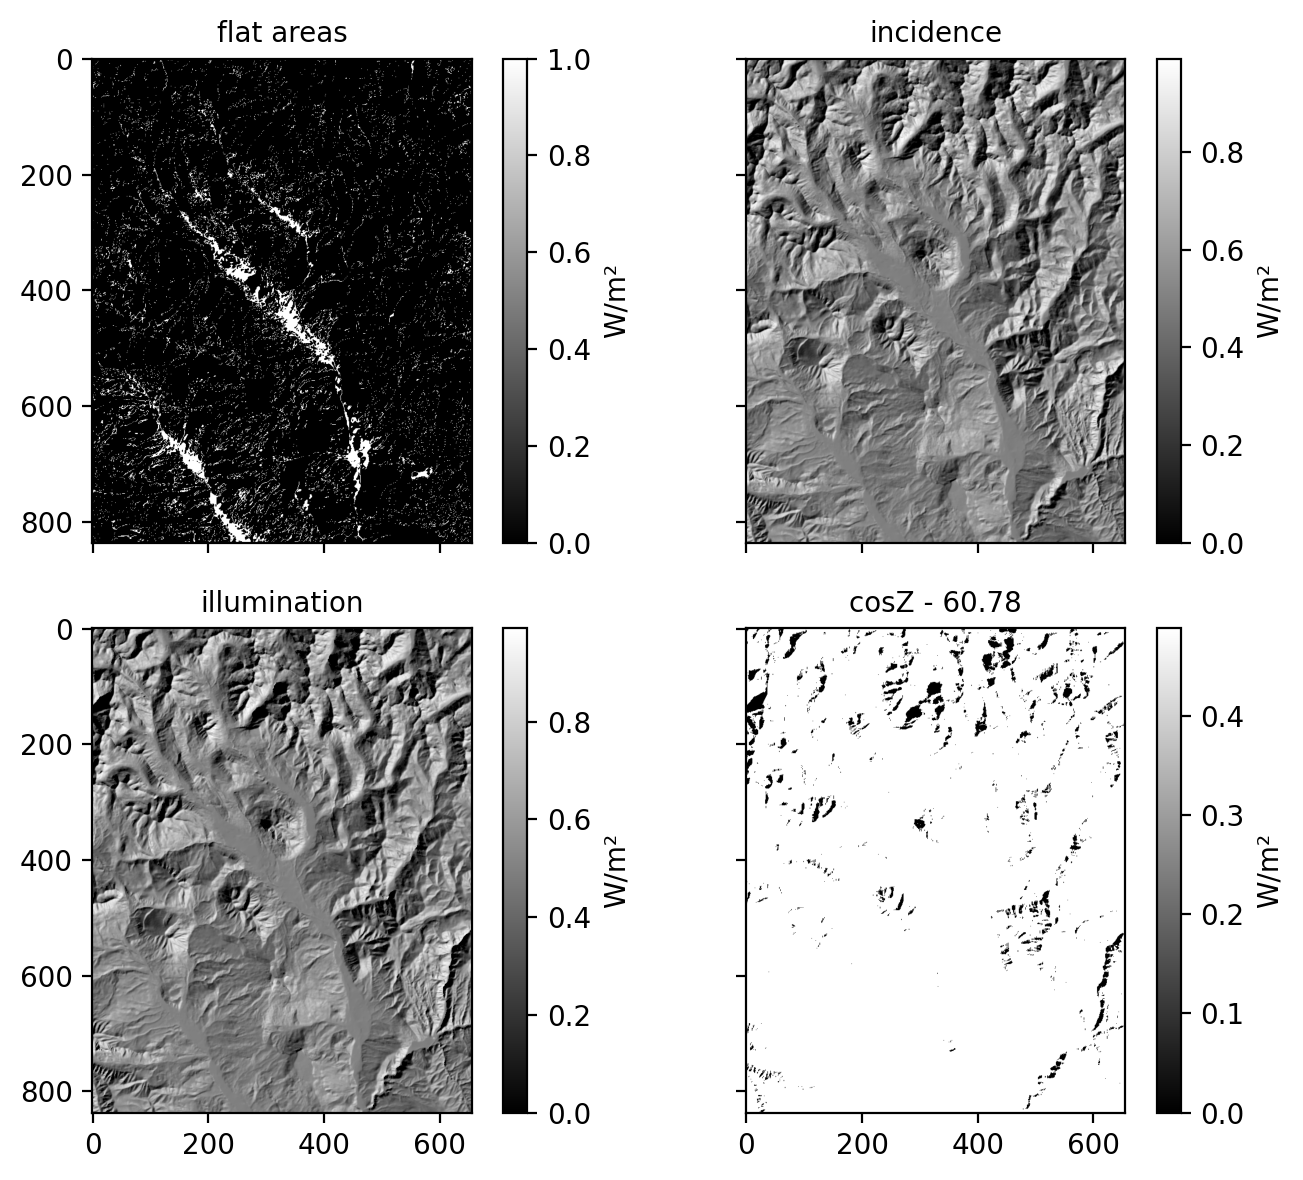

In [56]:
# PLOT MODELS
fig, ax = plt.subplots(ncols=2, nrows=2, dpi=200, figsize=(7,6), sharex=True, sharey=True)
ax = ax.flatten()

axes_args = dict(cmap='grey')
title_args = dict(fontsize=10)

timestep = '2022-03-01 16:00'
print(zenith[timestep])

# Plot and create colorbars
xor = (illumination[timestep] > round(m.cos(m.radians(zenith[timestep])),1)-0.01) & (illumination[timestep] < round(m.cos(m.radians(zenith[timestep])),1)+0.01)
im0 = ax[0].imshow(xor, **axes_args)
ax[0].set_title('flat areas', **title_args)
fig.colorbar(im0, ax=ax[0], label="W/m²")

im1 = ax[1].imshow(incidence[timestep], **axes_args)
ax[1].set_title('incidence', **title_args)
fig.colorbar(im1, ax=ax[1], label="W/m²")

im2 = ax[2].imshow(illumination[timestep], **axes_args)
ax[2].set_title('illumination', **title_args)
fig.colorbar(im2, ax=ax[2], label="W/m²")

im3 = ax[3].imshow(cosZ[timestep], **axes_args)
ax[3].set_title('cosZ - '+ str(round(zenith[timestep],2)), **title_args)
fig.colorbar(im3, ax=ax[3], label="W/m²")

plt.tight_layout()
plt.show()

In [49]:
cosZ[timestep]

array([[0.        , 0.        , 0.        , ..., 0.48817748, 0.48817748,
        0.48817748],
       [0.        , 0.        , 0.        , ..., 0.48817748, 0.48817748,
        0.48817748],
       [0.        , 0.        , 0.        , ..., 0.48817748, 0.48817748,
        0.48817748],
       ...,
       [0.48817748, 0.48817748, 0.48817748, ..., 0.48817748, 0.48817748,
        0.48817748],
       [0.48817748, 0.        , 0.48817748, ..., 0.48817748, 0.48817748,
        0.48817748],
       [0.48817748, 0.48817748, 0.48817748, ..., 0.48817748, 0.48817748,
        0.48817748]])

In [51]:
m.cos(m.radians(zenith[timestep]))

0.4881774791172619

## test functions

In [5]:
# load terrain variables
# dem, sky_view_factor, topo_shade = tsw.static_topo_vars(ERW_TOPO_FILE)
hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + 'hrrr.20220301/hrrr.t09z.wrfsfcf06.grib2', 'cubic')

# calculate solar geometry (FUll day)
azimuth, zenith, incidence_angles, illumination, cosZ = tsw.hrrr_solar_geom(hrrr_dswrf, topo_shade)

# run models
ghi, dsw1, dsw2, dsw3, dsw3h, k = tsw.toposplit(hrrr_dswrf, zenith, incidence_angles, illumination, cosZ, sky_view_factor)

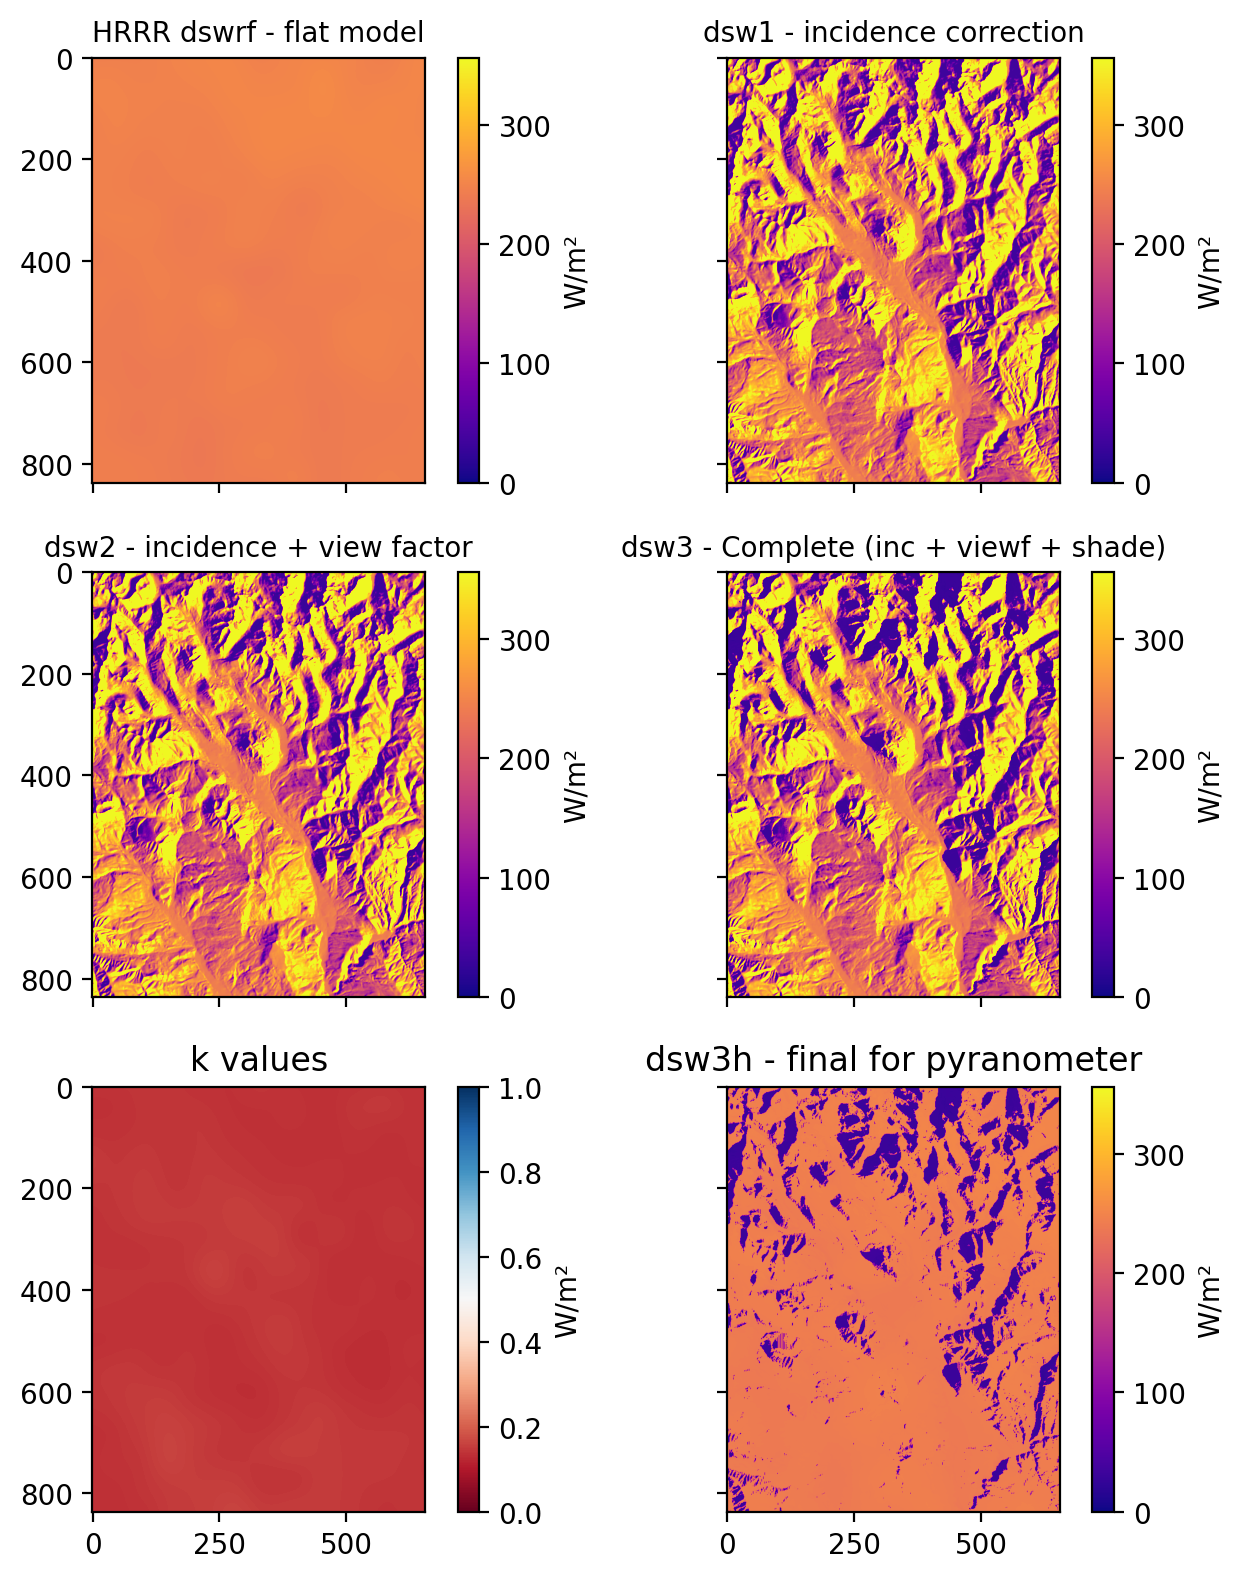

In [6]:
# PLOT MODELS
fig, ax = plt.subplots(ncols=2, nrows=3, dpi=200, figsize=(7,8), sharex=True, sharey=True)
ax = ax.flatten()

axes_args = dict(cmap='plasma', vmax=(ghi.max() + 100), vmin=0)
title_args = dict(fontsize=10)

# Plot and create colorbars
im0 = ax[0].imshow(ghi, **axes_args)
ax[0].set_title('HRRR dswrf - flat model', **title_args)
fig.colorbar(im0, ax=ax[0], label="W/m²")

im1 = ax[1].imshow(dsw1, **axes_args)
ax[1].set_title('dsw1 - incidence correction', **title_args)
fig.colorbar(im1, ax=ax[1], label="W/m²")

im2 = ax[2].imshow(dsw2, **axes_args)
ax[2].set_title('dsw2 - incidence + view factor', **title_args)
fig.colorbar(im2, ax=ax[2], label="W/m²")

im3 = ax[3].imshow(dsw3, **axes_args)
ax[3].set_title('dsw3 - Complete (inc + viewf + shade)', **title_args)
fig.colorbar(im3, ax=ax[3], label="W/m²")

im4 = ax[4].imshow(k, cmap='RdBu', vmin=0, vmax=1)
ax[4].set_title('k values')
fig.colorbar(im4, ax=ax[4], label="W/m²")

im5 = ax[5].imshow(dsw3h, **axes_args)
ax[5].set_title('dsw3h - final for pyranometer')
fig.colorbar(im5, ax=ax[5], label="W/m²")

plt.tight_layout()
plt.show()

In [9]:
# load terrain variables
# dem, sky_view_factor, topo_shade = tsw.static_topo_vars(ERW_TOPO_FILE)
hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + 'hrrr.20220301/hrrr.t14z.wrfsfcf06.grib2', 'cubic')

# calculate solar geometry (FUll day)
azimuth, zenith, incidence_angles, illumination, cosZ = tsw.hrrr_solar_geom(hrrr_dswrf, topo_shade)

# run models
ghi, dsw1, dsw2, dsw3, dsw3h, k = tsw.toposplit(hrrr_dswrf, zenith, incidence_angles, illumination, cosZ, sky_view_factor)

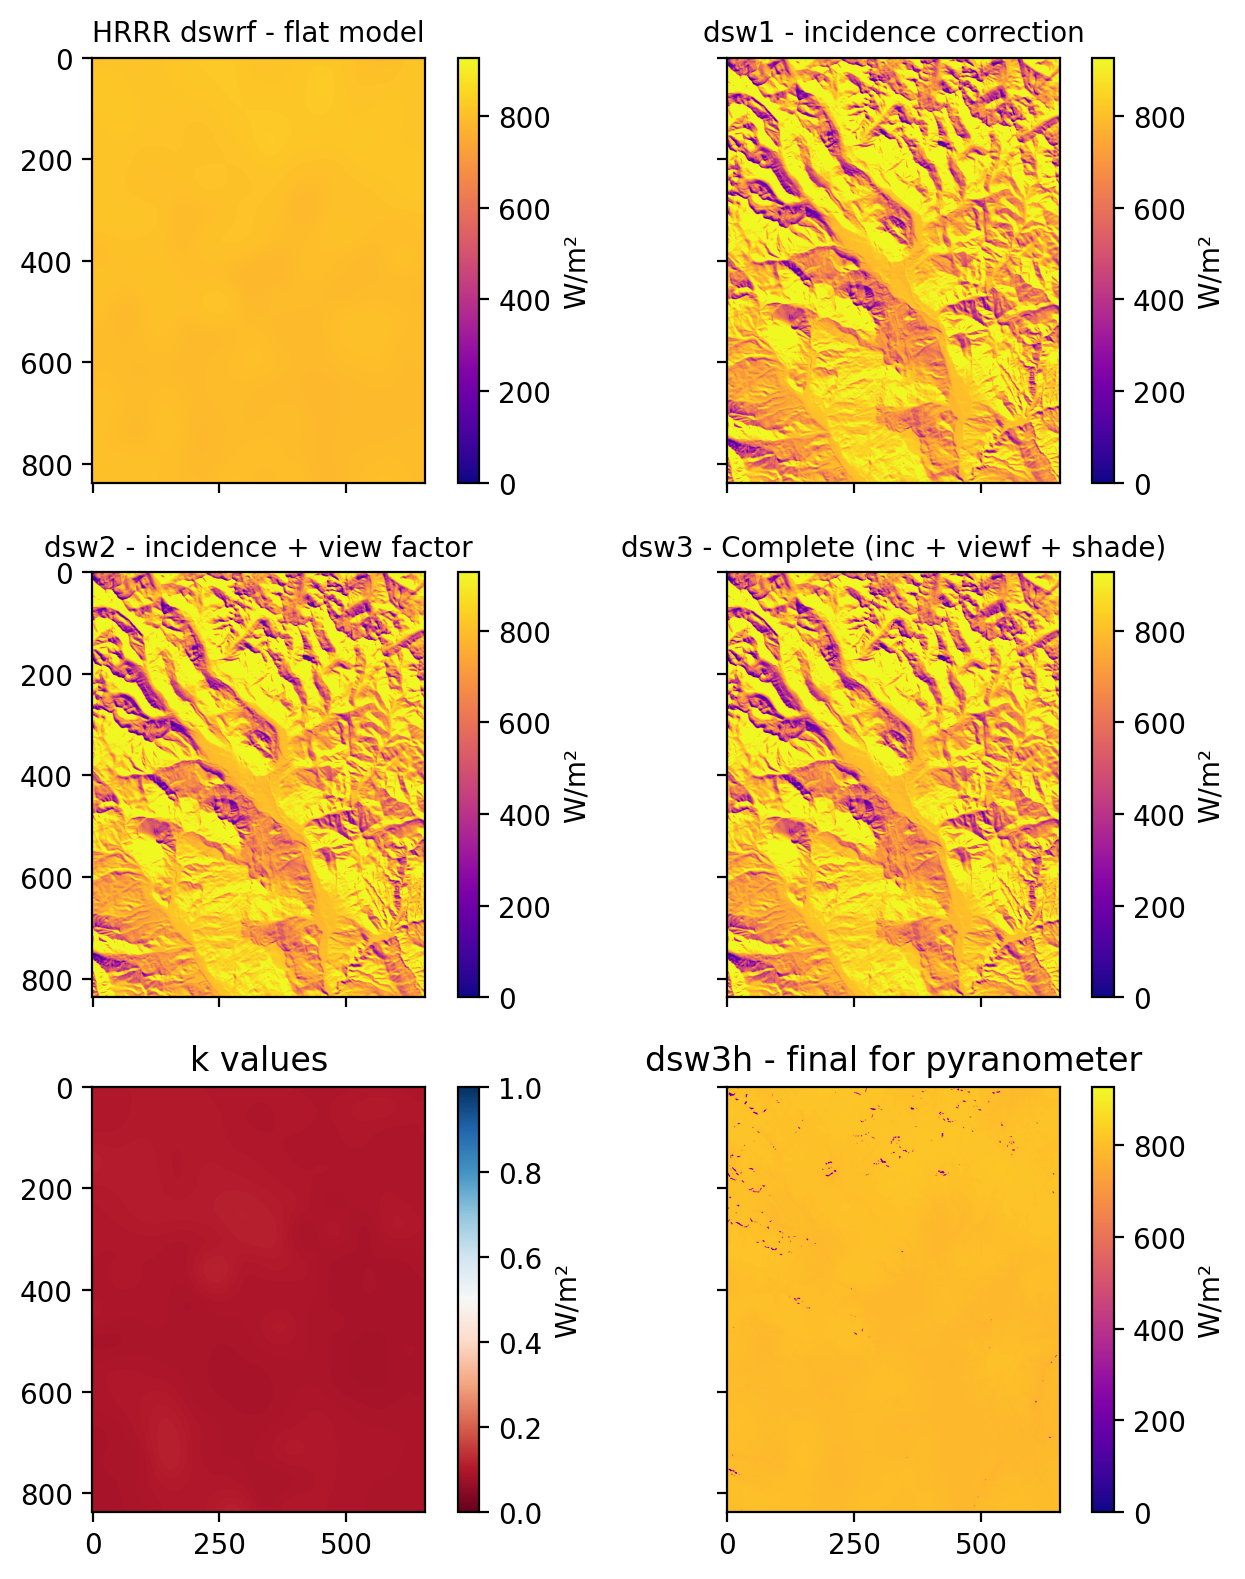

In [10]:
# PLOT MODELS
fig, ax = plt.subplots(ncols=2, nrows=3, dpi=200, figsize=(7,8), sharex=True, sharey=True)
ax = ax.flatten()

axes_args = dict(cmap='plasma', vmax=(ghi.max() + 100), vmin=0)
title_args = dict(fontsize=10)

# Plot and create colorbars
im0 = ax[0].imshow(ghi, **axes_args)
ax[0].set_title('HRRR dswrf - flat model', **title_args)
fig.colorbar(im0, ax=ax[0], label="W/m²")

im1 = ax[1].imshow(dsw1, **axes_args)
ax[1].set_title('dsw1 - incidence correction', **title_args)
fig.colorbar(im1, ax=ax[1], label="W/m²")

im2 = ax[2].imshow(dsw2, **axes_args)
ax[2].set_title('dsw2 - incidence + view factor', **title_args)
fig.colorbar(im2, ax=ax[2], label="W/m²")

im3 = ax[3].imshow(dsw3, **axes_args)
ax[3].set_title('dsw3 - Complete (inc + viewf + shade)', **title_args)
fig.colorbar(im3, ax=ax[3], label="W/m²")

im4 = ax[4].imshow(k, cmap='RdBu', vmin=0, vmax=1)
ax[4].set_title('k values')
fig.colorbar(im4, ax=ax[4], label="W/m²")

im5 = ax[5].imshow(dsw3h, **axes_args)
ax[5].set_title('dsw3h - final for pyranometer')
fig.colorbar(im5, ax=ax[5], label="W/m²")

plt.tight_layout()
plt.show()

In [12]:
k.mean()

0.0969380533483164

# Investigate k and dswr values

In [11]:
# run models
hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + 'hrrr.20220301/hrrr.t14z.wrfsfcf06.grib2', 'cubic')

hrrr = []
d1 = []
d2 = []
d3 = []
d4 = []
ks = []

# calculate solar geometry (Full day)
azimuth, zenith, incidence_angles, illumination, cosZ = tsw.hrrr_solar_geom(hrrr_dswrf, topo_shade)

for i in range(7, 19):
    print(i)
    hour_str = f't{str(i).zfill(2)}z'
    file_path = f'{HRRR_DATA}hrrr.20220301/hrrr.{hour_str}.wrfsfcf06.grib2'
    
    hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, file_path, 'cubic')

    ghi, dsw1, dsw2, dsw3, dsw3h, k = tsw.toposplit(
        hrrr_dswrf, zenith, incidence_angles, illumination, cosZ, sky_view_factor
    )

    # append hourly data
    hrrr.append(ghi.mean())
    d1.append(dsw1.mean())
    d2.append(dsw2.mean())
    d3.append(dsw3.mean())
    d4.append(dsw3h.mean())
    ks.append(k.mean() * 1000)


8
9
10
11
12
13
14
15
16
17
18


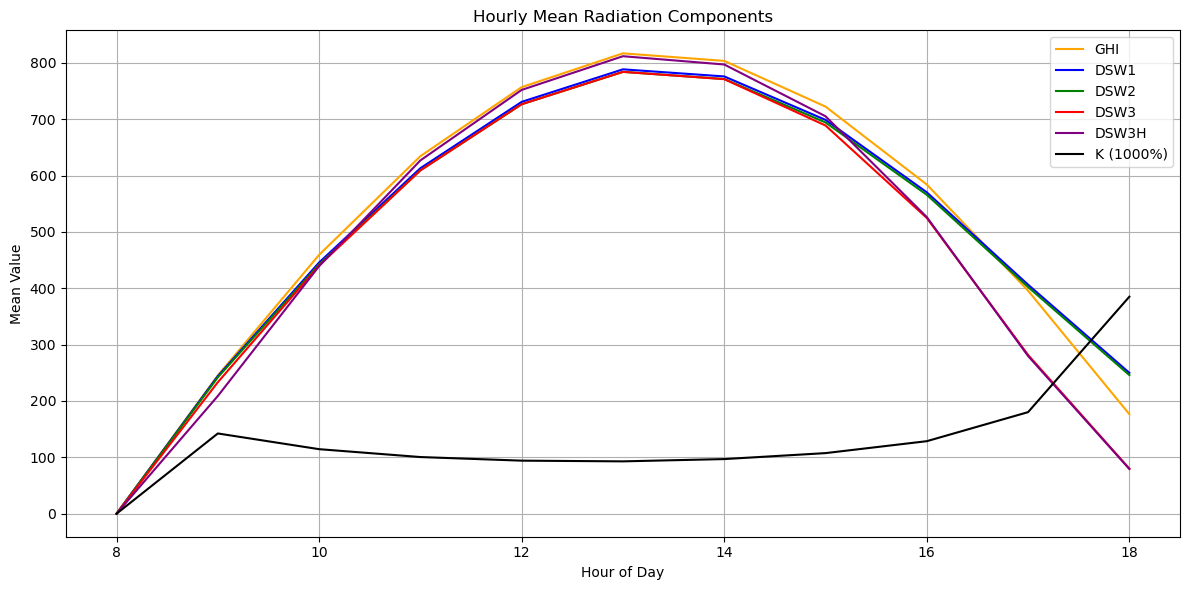

In [12]:

# x-axis representing the hours of the day
hours = list(range(8,19))

# Plot each variable with a different color and label
plt.figure(figsize=(12, 6))
plt.plot(hours, hrrr, label='GHI', color='orange')
plt.plot(hours, d1, label='DSW1', color='blue')
plt.plot(hours, d2, label='DSW2', color='green')
plt.plot(hours, d3, label='DSW3', color='red')
plt.plot(hours, d4, label='DSW3H', color='purple')
plt.plot(hours, ks, label='K (1000%)', color='black')

# Add labels and title
plt.xlabel('Hour of Day')
plt.ylabel('Mean Value')
plt.title('Hourly Mean Radiation Components')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()



K value is a bit lower than expected. Also might be a good idea to fix logic so that any small values early and late still have higher k values

# Day Function

In [8]:
hrrr_dir = HRRR_DATA + 'hrrr.20220315'
ghi_stack, dsw1_stack, dsw2_stack, dsw3_stack, dsw3h_stack, k_stack, time_list = tsw.toposplit_for_day(ERW_TOPO_FILE, hrrr_dir, resample_method='cubic')

  K: 0.0
  K: 0.19
  K: 0.14
  K: 0.11
  K: 0.1
  K: 0.1
  K: 0.1
  K: 0.1
  K: 0.11
  K: 0.13
  K: 0.18
  K: 0.34
  K: 0.82


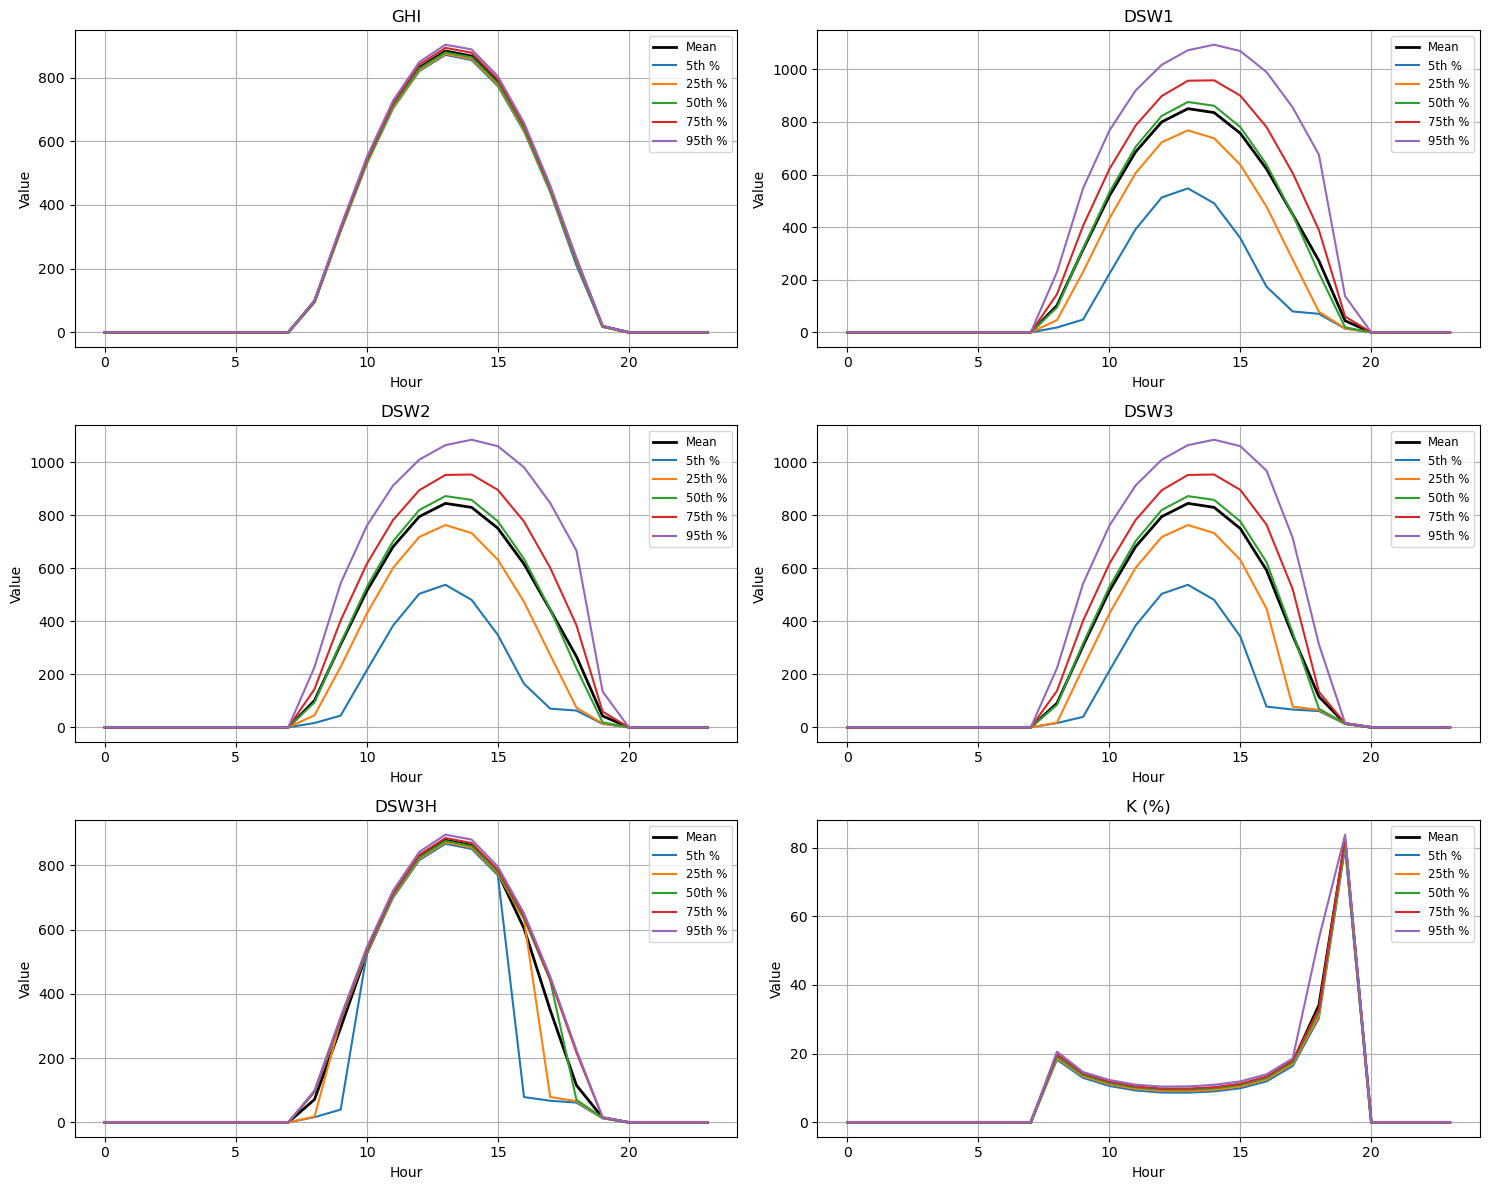

In [10]:
# QUANTILE VALUES

# Arrays: shape (24, H, W)
arrays = {
    'GHI': ghi_stack,
    'DSW1': dsw1_stack,
    'DSW2': dsw2_stack,
    'DSW3': dsw3_stack,
    'DSW3H': dsw3h_stack,
    'K (%)': k_stack * 100,  # Convert to percentage for readability
}

# Time axis: 0–23 hours
hours = np.arange(24)

# Quantiles to compute
quantiles = [5, 25, 50, 75, 95]

# Create figure
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

# Loop through each variable
for ax, (label, arr) in zip(axes, arrays.items()):
    mean_vals = arr.mean(axis=(1, 2))
    q_vals = np.percentile(arr, quantiles, axis=(1, 2))  # shape: (5, 24)

    ax.plot(hours, mean_vals, label='Mean', color='black', linewidth=2)
    for q, vals in zip(quantiles, q_vals):
        ax.plot(hours, vals, label=f'{q}th %')

    ax.set_title(label)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend(loc='upper right', fontsize='small')

plt.tight_layout()
svpth = '/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/'
# plt.savefig(svpth+ "toposplit-models-by-elevation.png", dpi=300)  # You can change filename and format
# plt.close()
plt.show()


Elevation Ranges (m):
E1 (Low): 2440.31 – 3069.41 m
E2 (Mid): 3069.41 – 3698.51 m
E3 (High): 3698.51 – 4327.61 m


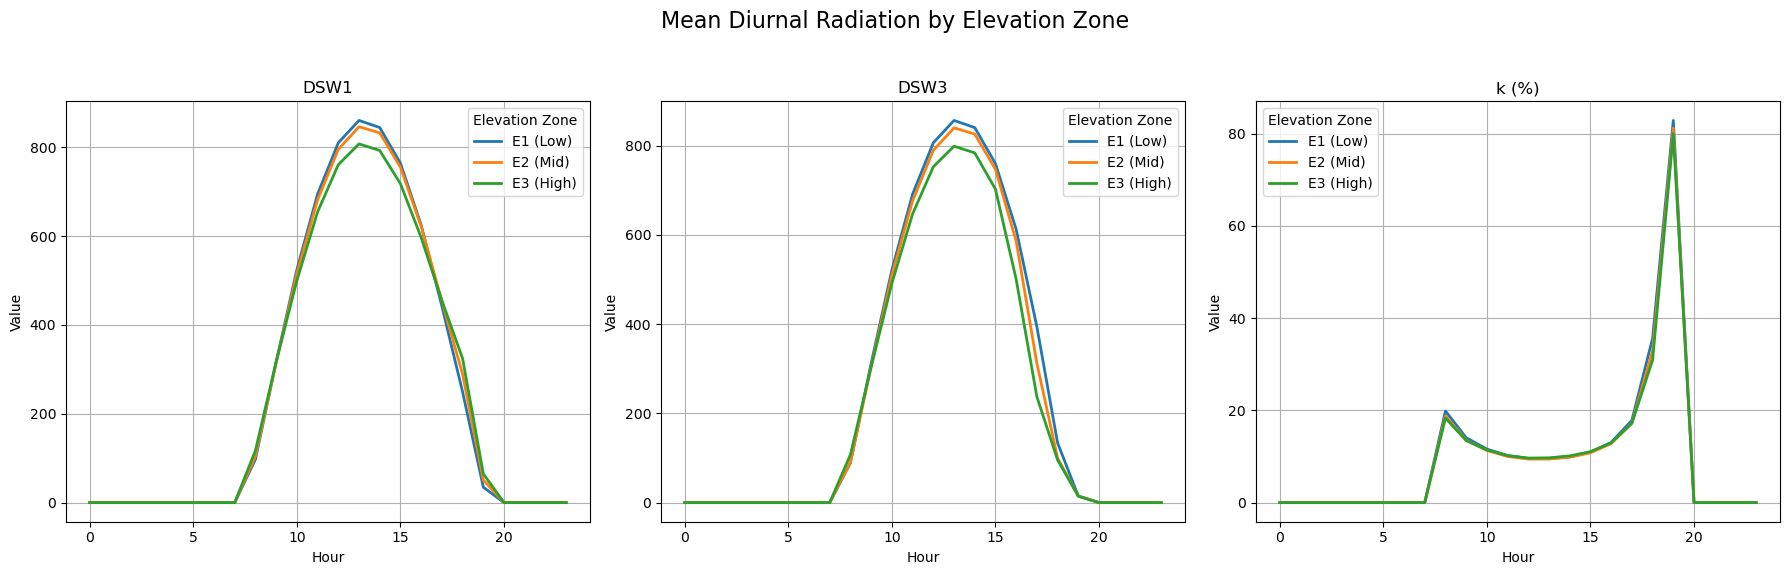

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Select variables to plot
arrays = {
    'DSW1': dsw1_stack,
    'DSW3': dsw3_stack,
    'k (%)': k_stack * 100  # Convert k to percent
}

# Time axis (0 to 23 hours)
hours = np.arange(24)

# Define 3 elevation bins using dem
n_bins = 3
bin_labels = ['E1 (Low)', 'E2 (Mid)', 'E3 (High)']
elev_edges = np.linspace(dem.min(), dem.max(), n_bins + 1)

# Create elevation masks
elevation_masks = [
    (dem >= elev_edges[i]) & (dem < elev_edges[i + 1])
    for i in range(n_bins)
]
# Ensure max is included in last bin
elevation_masks[-1] = (dem >= elev_edges[-2]) & (dem <= elev_edges[-1])

# Print bin info
print("Elevation Ranges (m):")
for i, label in enumerate(bin_labels):
    print(f"{label}: {elev_edges[i]:.2f} – {elev_edges[i+1]:.2f} m")

# Plot
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=False)

colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, (label, arr) in zip(axes, arrays.items()):
    for i, mask in enumerate(elevation_masks):
        # Broadcast mask and extract time series
        masked = np.where(mask, arr, np.nan)
        mean_vals = np.nanmean(masked, axis=(1, 2))  # Mean over spatial dims
        ax.plot(hours, mean_vals, label=bin_labels[i], color=colors[i], linewidth=2)

    ax.set_title(label)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend(title='Elevation Zone')

plt.suptitle("Mean Diurnal Radiation by Elevation Zone", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## By elevation

In [9]:
# Define number of elevation quantiles
n_quantiles = 5

# Calculate elevation quantile edges
elev_edges = np.percentile(dem, np.linspace(0, 100, n_quantiles + 1))

# Print quantile ranges
print("Elevation Quantile Ranges (meters):")
for i in range(n_quantiles):
    lower = elev_edges[i]
    upper = elev_edges[i + 1]
    print(f"Q{i+1}: {lower:.2f} m – {upper:.2f} m")


Elevation Quantile Ranges (meters):
Q1: 2440.31 m – 2770.68 m
Q2: 2770.68 m – 2978.73 m
Q3: 2978.73 m – 3200.29 m
Q4: 3200.29 m – 3445.32 m
Q5: 3445.32 m – 4327.61 m


/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/smeshr/lib/python3.10/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


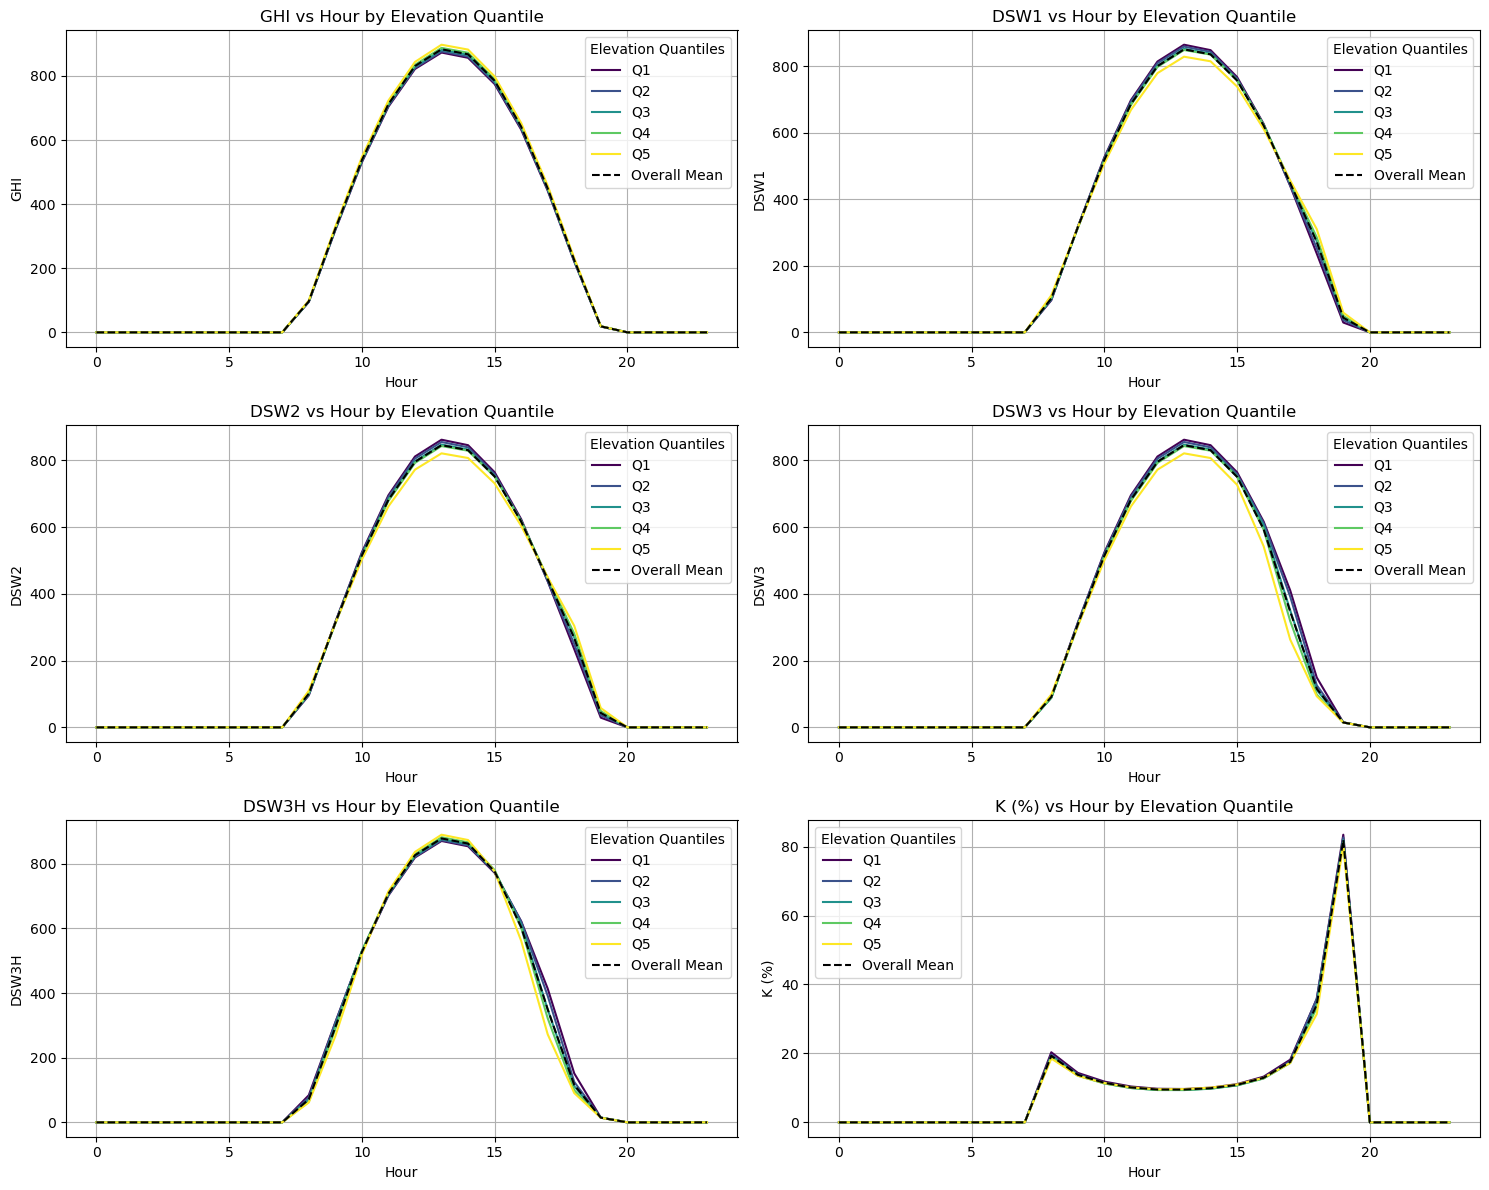

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define number of elevation quantile groups (e.g., 5)
n_quantiles = 5

# Step 1: Compute elevation quantile edges and masks
elev_edges = np.percentile(dem, np.linspace(0, 100, n_quantiles + 1))
quantile_masks = [
    (dem >= elev_edges[i]) & (dem < elev_edges[i + 1])
    for i in range(n_quantiles)
]

# Optional: last bin includes max elevation
quantile_masks[-1] = (dem >= elev_edges[-2]) & (dem <= elev_edges[-1])

# Step 2: Prepare radiation arrays
arrays = {
    'GHI': ghi_stack,
    'DSW1': dsw1_stack,
    'DSW2': dsw2_stack,
    'DSW3': dsw3_stack,
    'DSW3H': dsw3h_stack,
    'K (%)': k_stack * 100
}

# Step 3: Plot per-elevation-quantile time series
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

hours = np.arange(24)
colors = plt.cm.viridis(np.linspace(0, 1, n_quantiles))

for ax, (name, arr) in zip(axes, arrays.items()):
    for q, mask in enumerate(quantile_masks):
        # Create a masked 3D array for each quantile
        masked_vals = np.where(mask, arr, np.nan)  # shape: (24, H, W)
        mean_vals = np.nanmean(masked_vals, axis=(1, 2))  # per hour

        ax.plot(hours, mean_vals, label=f'Q{q+1}', color=colors[q])

    # Plot overall spatial mean
    overall_mean = arr.mean(axis=(1, 2))
    ax.plot(hours, overall_mean, label='Overall Mean', color='black', linestyle='--', linewidth=1.5)

    ax.set_title(f'{name} vs Hour by Elevation Quantile')
    ax.set_xlabel('Hour')
    ax.set_ylabel(name)
    ax.grid(True)
    ax.legend(title='Elevation Quantiles')

plt.tight_layout()
# plt.savefig('radiation_by_elevation_quantile.png', dpi=300)
# plt.show()
plt.show()

In [10]:
# Define 3 elevation bins: low (E1), mid (E2), high (E3)
n_bins = 3
bin_labels = ['E1 (Low)', 'E2 (Mid)', 'E3 (High)']

# Calculate equal-sized elevation bins (terciles)
elev_edges = np.percentile(dem, np.linspace(0, 100, n_bins + 1))

# Create masks for each elevation bin
elevation_masks = [
    (dem >= elev_edges[i]) & (dem < elev_edges[i + 1])
    for i in range(n_bins)
]
elevation_masks[-1] = (dem >= elev_edges[-2]) & (dem <= elev_edges[-1])  # include max in last bin

# Print elevation bin ranges
print("Elevation Bin Ranges (meters):")
for i, label in enumerate(bin_labels):
    lower = elev_edges[i]
    upper = elev_edges[i + 1]
    print(f"{label}: {lower:.2f} m – {upper:.2f} m")


Elevation Bin Ranges (meters):
E1 (Low): 2440.31 m – 2910.24 m
E2 (Mid): 2910.24 m – 3277.85 m
E3 (High): 3277.85 m – 4327.61 m


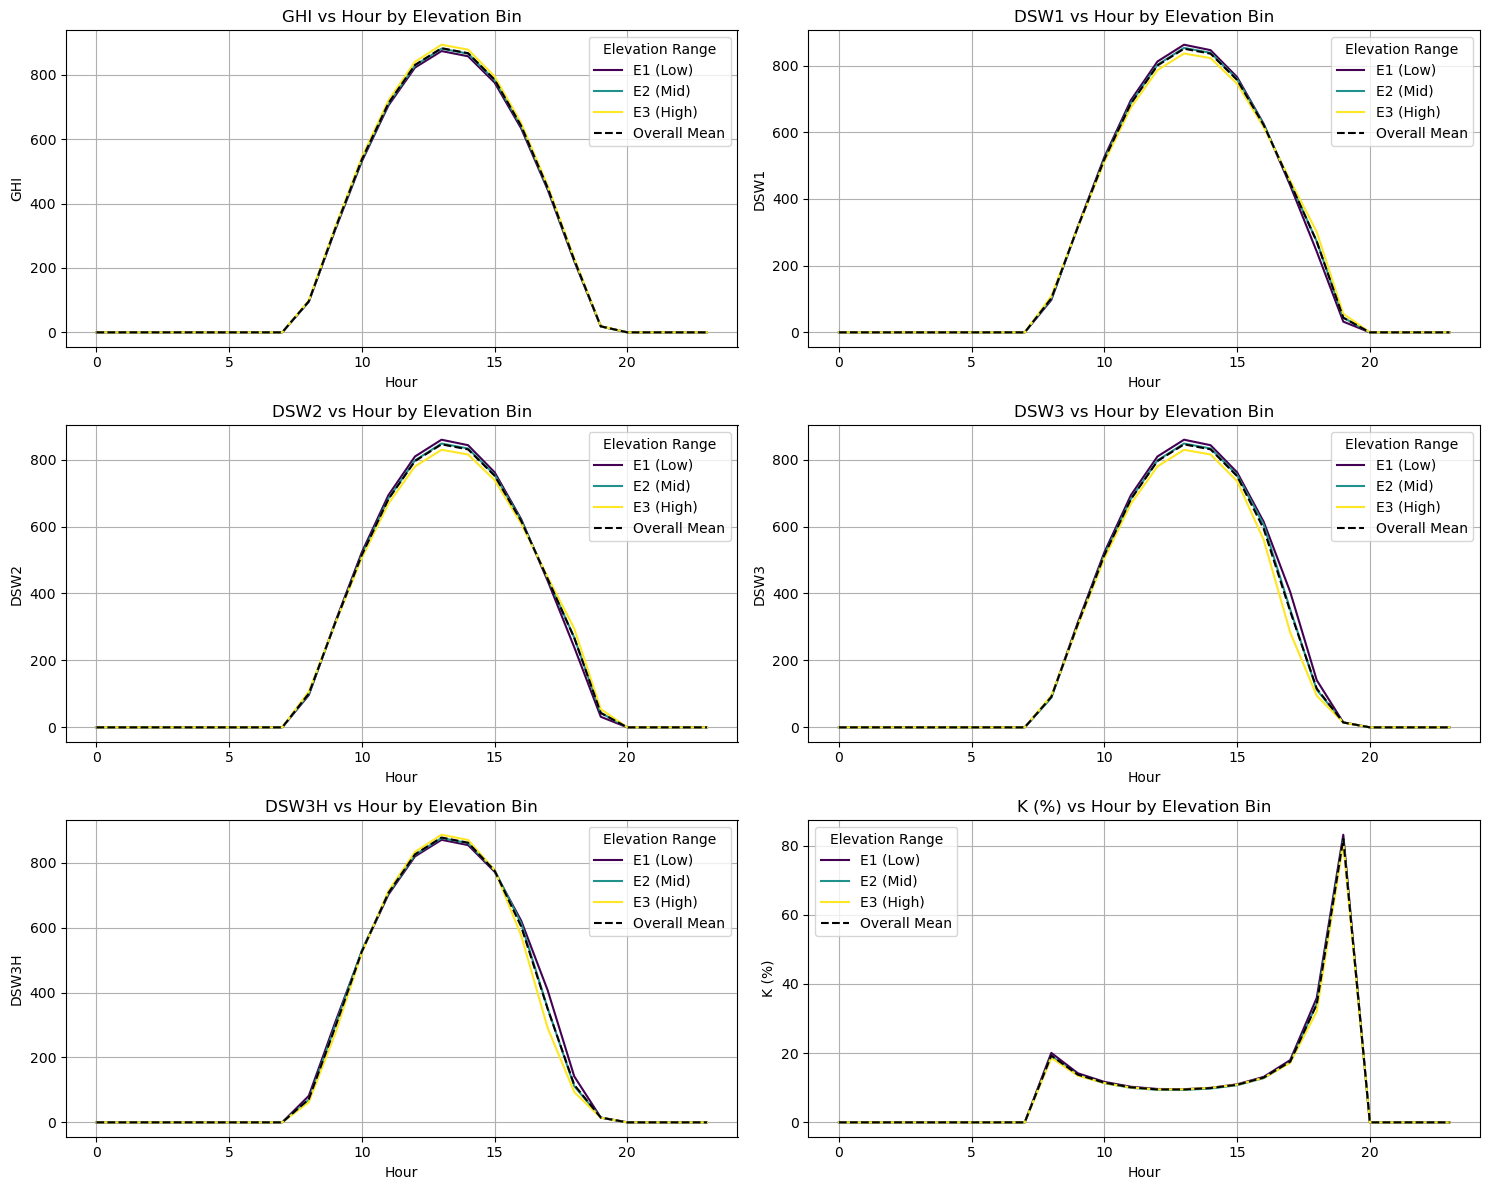

In [13]:
# Step 3: Plot per-elevation-quantile time series
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

hours = np.arange(24)
colors = plt.cm.viridis(np.linspace(0, 1, n_bins))

for ax, (name, arr) in zip(axes, arrays.items()):
    for i, (mask, label) in enumerate(zip(elevation_masks, bin_labels)):
        masked_vals = np.where(mask, arr, np.nan)
        mean_vals = np.nanmean(masked_vals, axis=(1, 2))
        ax.plot(hours, mean_vals, label=label, color=colors[i])

    overall_mean = arr.mean(axis=(1, 2))
    ax.plot(hours, overall_mean, label='Overall Mean', color='black', linestyle='--', linewidth=1.5)

    ax.set_title(f'{name} vs Hour by Elevation Bin')
    ax.set_xlabel('Hour')
    ax.set_ylabel(name)
    ax.grid(True)
    ax.legend(title='Elevation Range')

plt.tight_layout()
# plt.savefig('radiation_by_elevation_sets3.png', dpi=300)
# plt.show()
plt.show()

Elevation Bin Ranges (meters):
E1 (Low): 2440.31 m – 2910.24 m
E2 (Mid): 2910.24 m – 3277.85 m
E3 (High): 3277.85 m – 4327.61 m


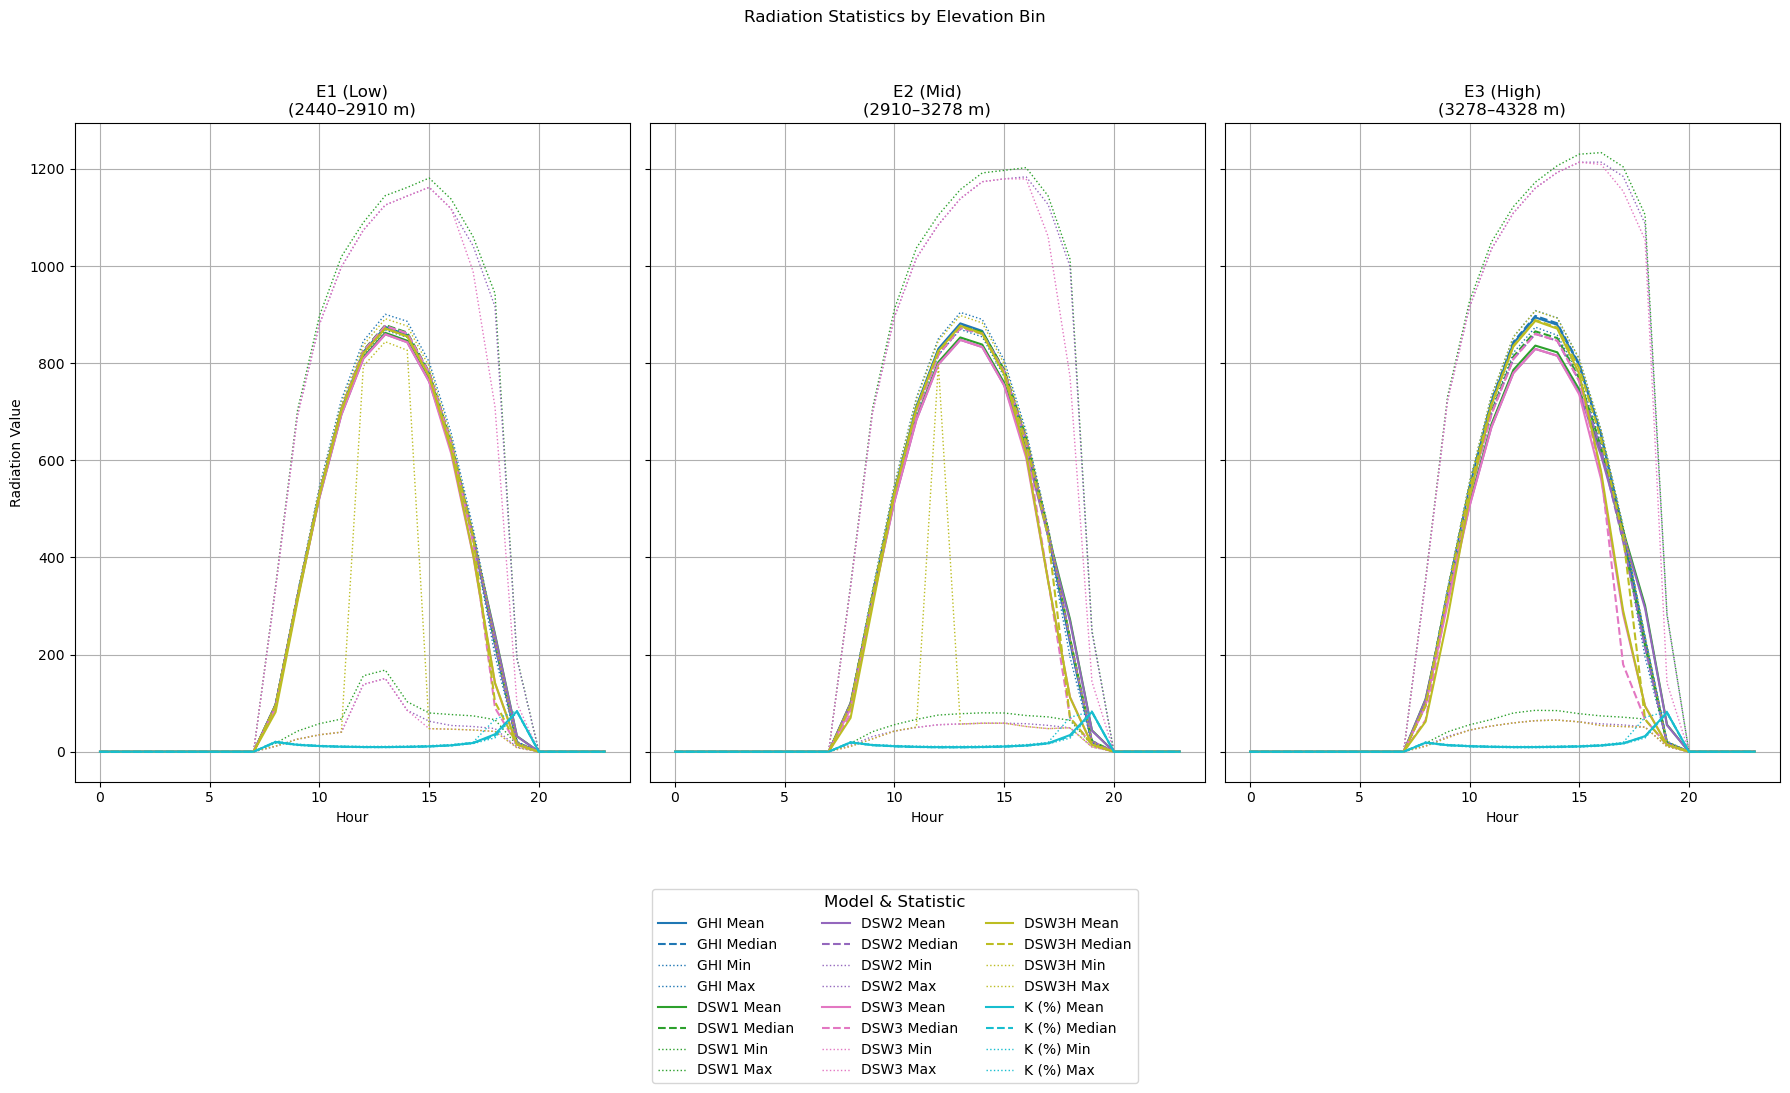

In [18]:


# Labels and data
arrays = {
    'GHI': ghi_stack,
    'DSW1': dsw1_stack,
    'DSW2': dsw2_stack,
    'DSW3': dsw3_stack,
    'DSW3H': dsw3h_stack,
    'K (%)': k_stack * 100
}

array_names = list(arrays.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(array_names)))

# Define 3 elevation bins (equal terciles)
n_bins = 3
bin_labels = ['E1 (Low)', 'E2 (Mid)', 'E3 (High)']
elev_edges = np.percentile(dem, np.linspace(0, 100, n_bins + 1))
elevation_masks = [
    (dem >= elev_edges[i]) & (dem < elev_edges[i + 1])
    for i in range(n_bins)
]
elevation_masks[-1] = (dem >= elev_edges[-2]) & (dem <= elev_edges[-1])  # include max

# Print bin ranges
print("Elevation Bin Ranges (meters):")
for i, label in enumerate(bin_labels):
    print(f"{label}: {elev_edges[i]:.2f} m – {elev_edges[i+1]:.2f} m")

# Time axis
hours = np.arange(24)

# Plot: one subplot per elevation bin
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 10), sharey=True)  # Taller figure

for ax, (mask, bin_label) in zip(axes, zip(elevation_masks, bin_labels)):
    for i, (name, arr) in enumerate(arrays.items()):
        masked = np.where(mask, arr, np.nan)

        mean_vals = np.nanmean(masked, axis=(1, 2))
        median_vals = np.nanmedian(masked, axis=(1, 2))
        min_vals = np.nanmin(masked, axis=(1, 2))
        max_vals = np.nanmax(masked, axis=(1, 2))

        ax.plot(hours, mean_vals, label=f'{name} Mean', color=colors[i], linestyle='-')
        ax.plot(hours, median_vals, label=f'{name} Median', color=colors[i], linestyle='--')
        ax.plot(hours, min_vals, label=f'{name} Min', color=colors[i], linestyle=':', linewidth=1)
        ax.plot(hours, max_vals, label=f'{name} Max', color=colors[i], linestyle=':', linewidth=1)

    ax.set_title(f'{bin_label}\n({elev_edges[bin_labels.index(bin_label)]:.0f}–{elev_edges[bin_labels.index(bin_label)+1]:.0f} m)')
    ax.set_xlabel('Hour')
    ax.grid(True)

axes[0].set_ylabel('Radiation Value')
# axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small', title='Model & Stat')

# Add shared legend at bottom
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    fontsize='medium',
    title='Model & Statistic',
    title_fontsize='large'
)

plt.suptitle('Radiation Statistics by Elevation Bin')
plt.tight_layout(rect=[0, 0.15, 1, 0.95])
plt.show()


Elevation Bin Ranges (meters):
E1 (Low): 2440.31 m – 2910.24 m
E2 (Mid): 2910.24 m – 3277.85 m
E3 (High): 3277.85 m – 4327.61 m


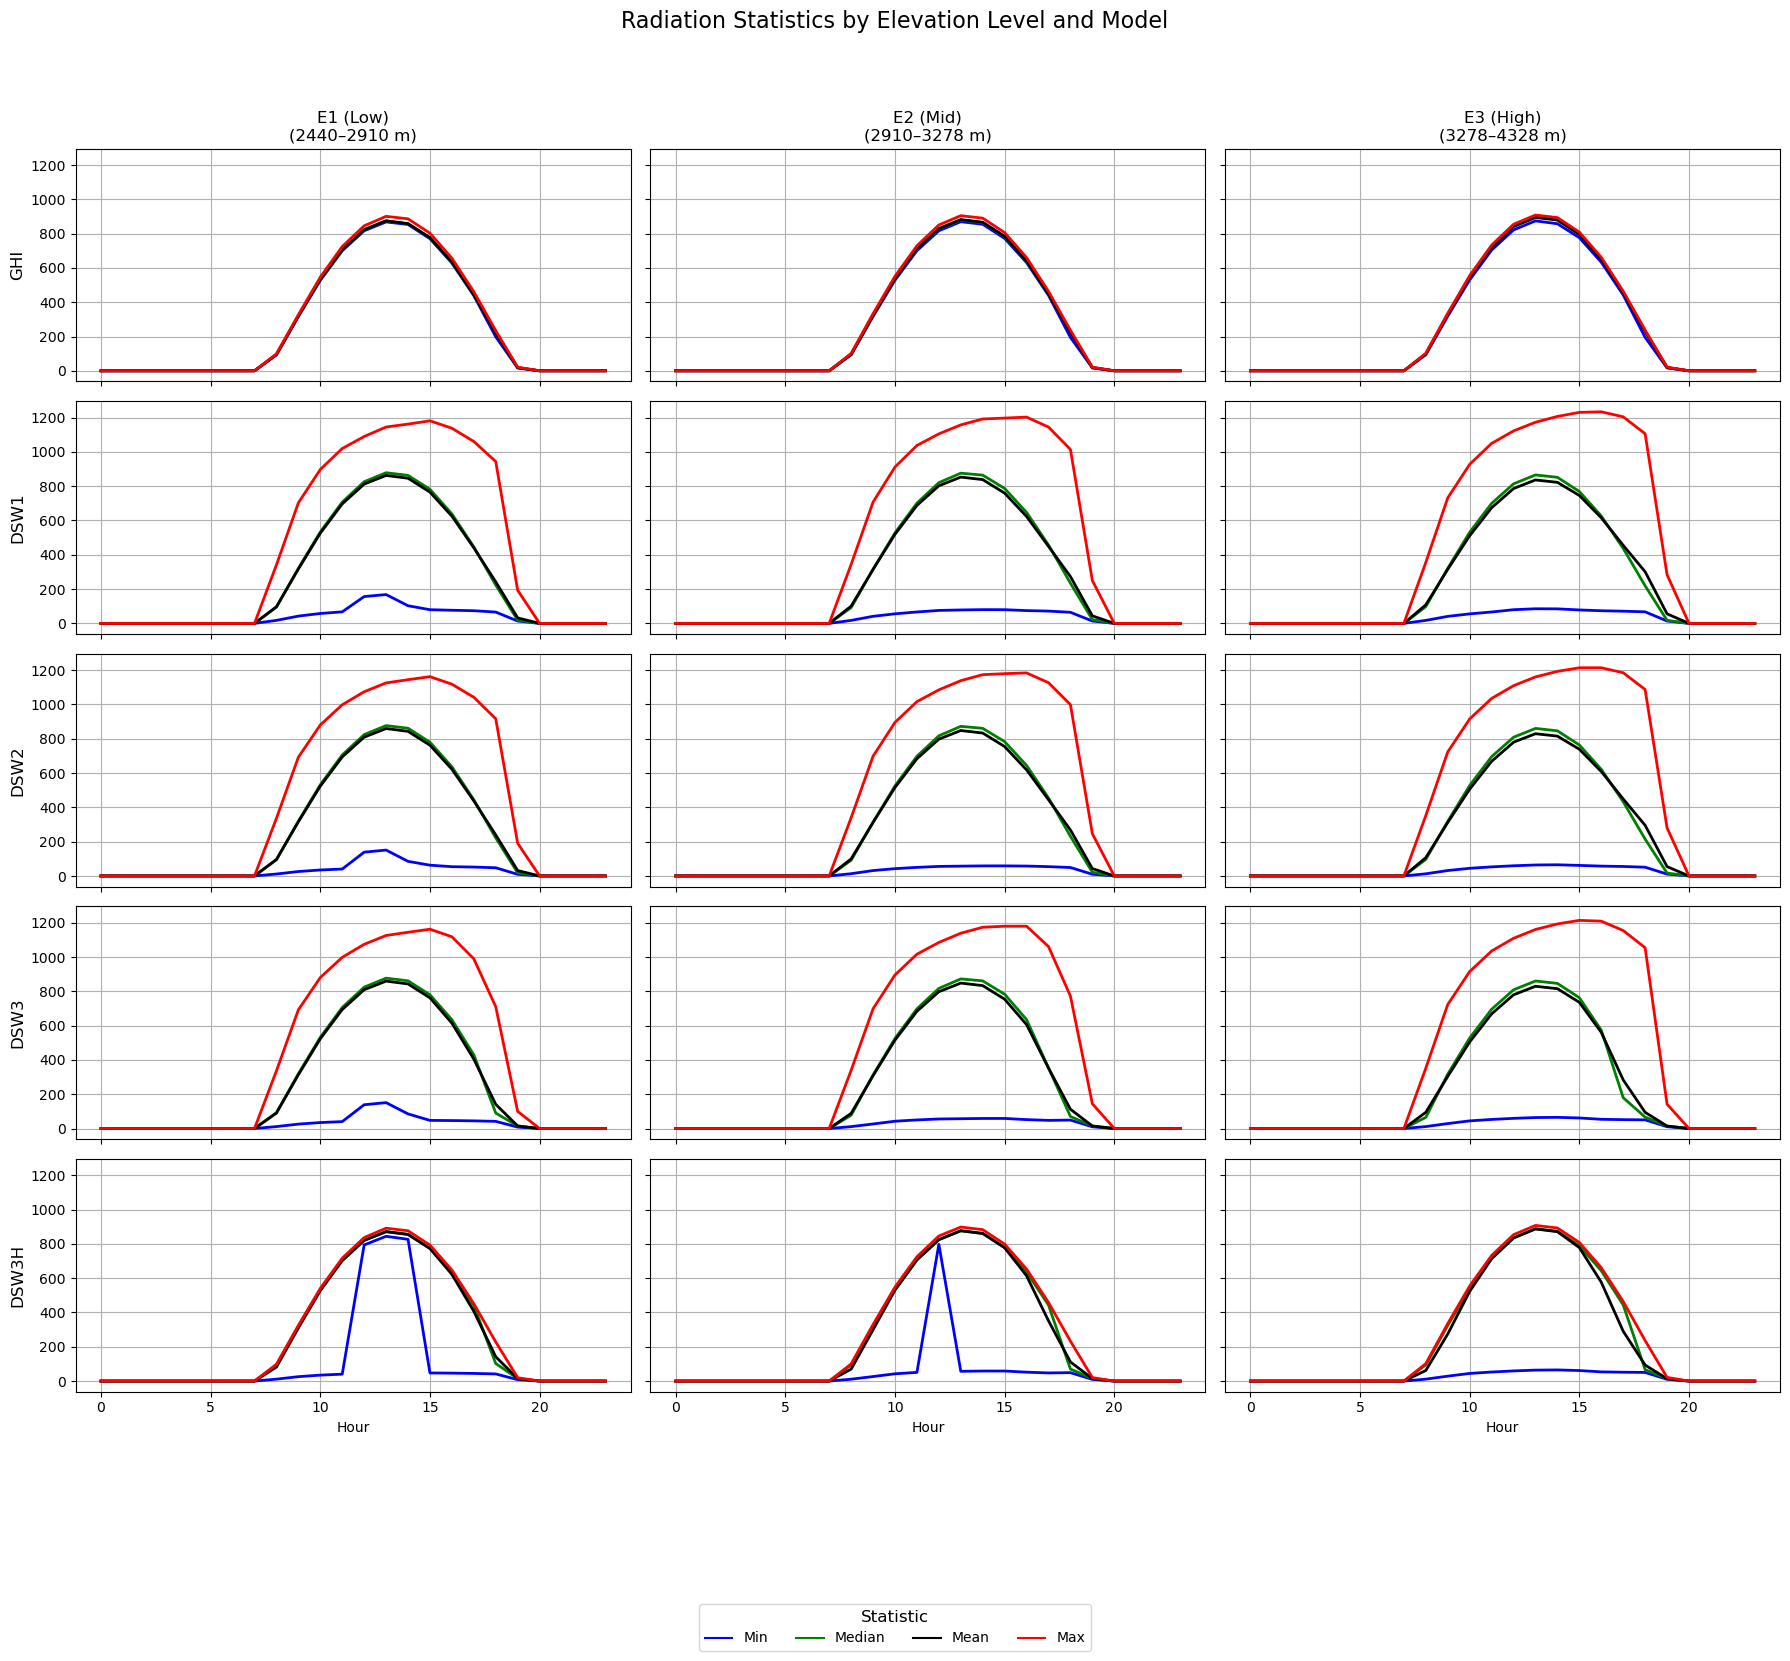

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Filtered arrays (drop 'K')
arrays = {
    'GHI': ghi_stack,
    'DSW1': dsw1_stack,
    'DSW2': dsw2_stack,
    'DSW3': dsw3_stack,
    'DSW3H': dsw3h_stack
}
array_names = list(arrays.keys())

# Time axis
hours = np.arange(24)

# Define 3 elevation bins (equal terciles)
n_bins = 3
bin_labels = ['E1 (Low)', 'E2 (Mid)', 'E3 (High)']
elev_edges = np.percentile(dem, np.linspace(0, 100, n_bins + 1))
elevation_masks = [
    (dem >= elev_edges[i]) & (dem < elev_edges[i + 1])
    for i in range(n_bins)
]
elevation_masks[-1] = (dem >= elev_edges[-2]) & (dem <= elev_edges[-1])  # include max

# Print elevation bin ranges
print("Elevation Bin Ranges (meters):")
for i, label in enumerate(bin_labels):
    print(f"{label}: {elev_edges[i]:.2f} m – {elev_edges[i+1]:.2f} m")

# Stats and colors
stats = ['Min', 'Median', 'Mean', 'Max']
stat_funcs = [np.nanmin, np.nanmedian, np.nanmean, np.nanmax]
stat_colors = ['blue', 'green', 'black', 'red']

# Plot layout: rows = radiation models, cols = elevation bins
fig, axes = plt.subplots(
    nrows=len(arrays), ncols=n_bins,
    figsize=(18, 16),  # increase height from e.g., 12 to 16
    sharex=True, sharey=True
)


for row_idx, (name, arr) in enumerate(arrays.items()):
    for col_idx, (mask, bin_label) in enumerate(zip(elevation_masks, bin_labels)):
        ax = axes[row_idx, col_idx]
        masked = np.where(mask, arr, np.nan)

        for func, stat_name, color in zip(stat_funcs, stats, stat_colors):
            stat_vals = func(masked, axis=(1, 2))
            ax.plot(hours, stat_vals, label=stat_name, color=color, linewidth=2)

        if row_idx == 0:
            ax.set_title(f'{bin_label}\n({elev_edges[col_idx]:.0f}–{elev_edges[col_idx+1]:.0f} m)')

        if col_idx == 0:
            ax.set_ylabel(f'{name}', fontsize=12)

        ax.grid(True)
        if row_idx == len(arrays) - 1:
            ax.set_xlabel('Hour')

# Shared legend at bottom
handles = [plt.Line2D([0], [0], color=color, label=stat) for stat, color in zip(stats, stat_colors)]
fig.legend(
    handles, stats,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    fontsize='medium',
    title='Statistic',
    title_fontsize='large'
)

plt.suptitle('Radiation Statistics by Elevation Level and Model', fontsize=16)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()


Elevation Bin Ranges (meters):
E1 (Low): 2440.31 m – 2910.24 m
E2 (Mid): 2910.24 m – 3277.85 m
E3 (High): 3277.85 m – 4327.61 m


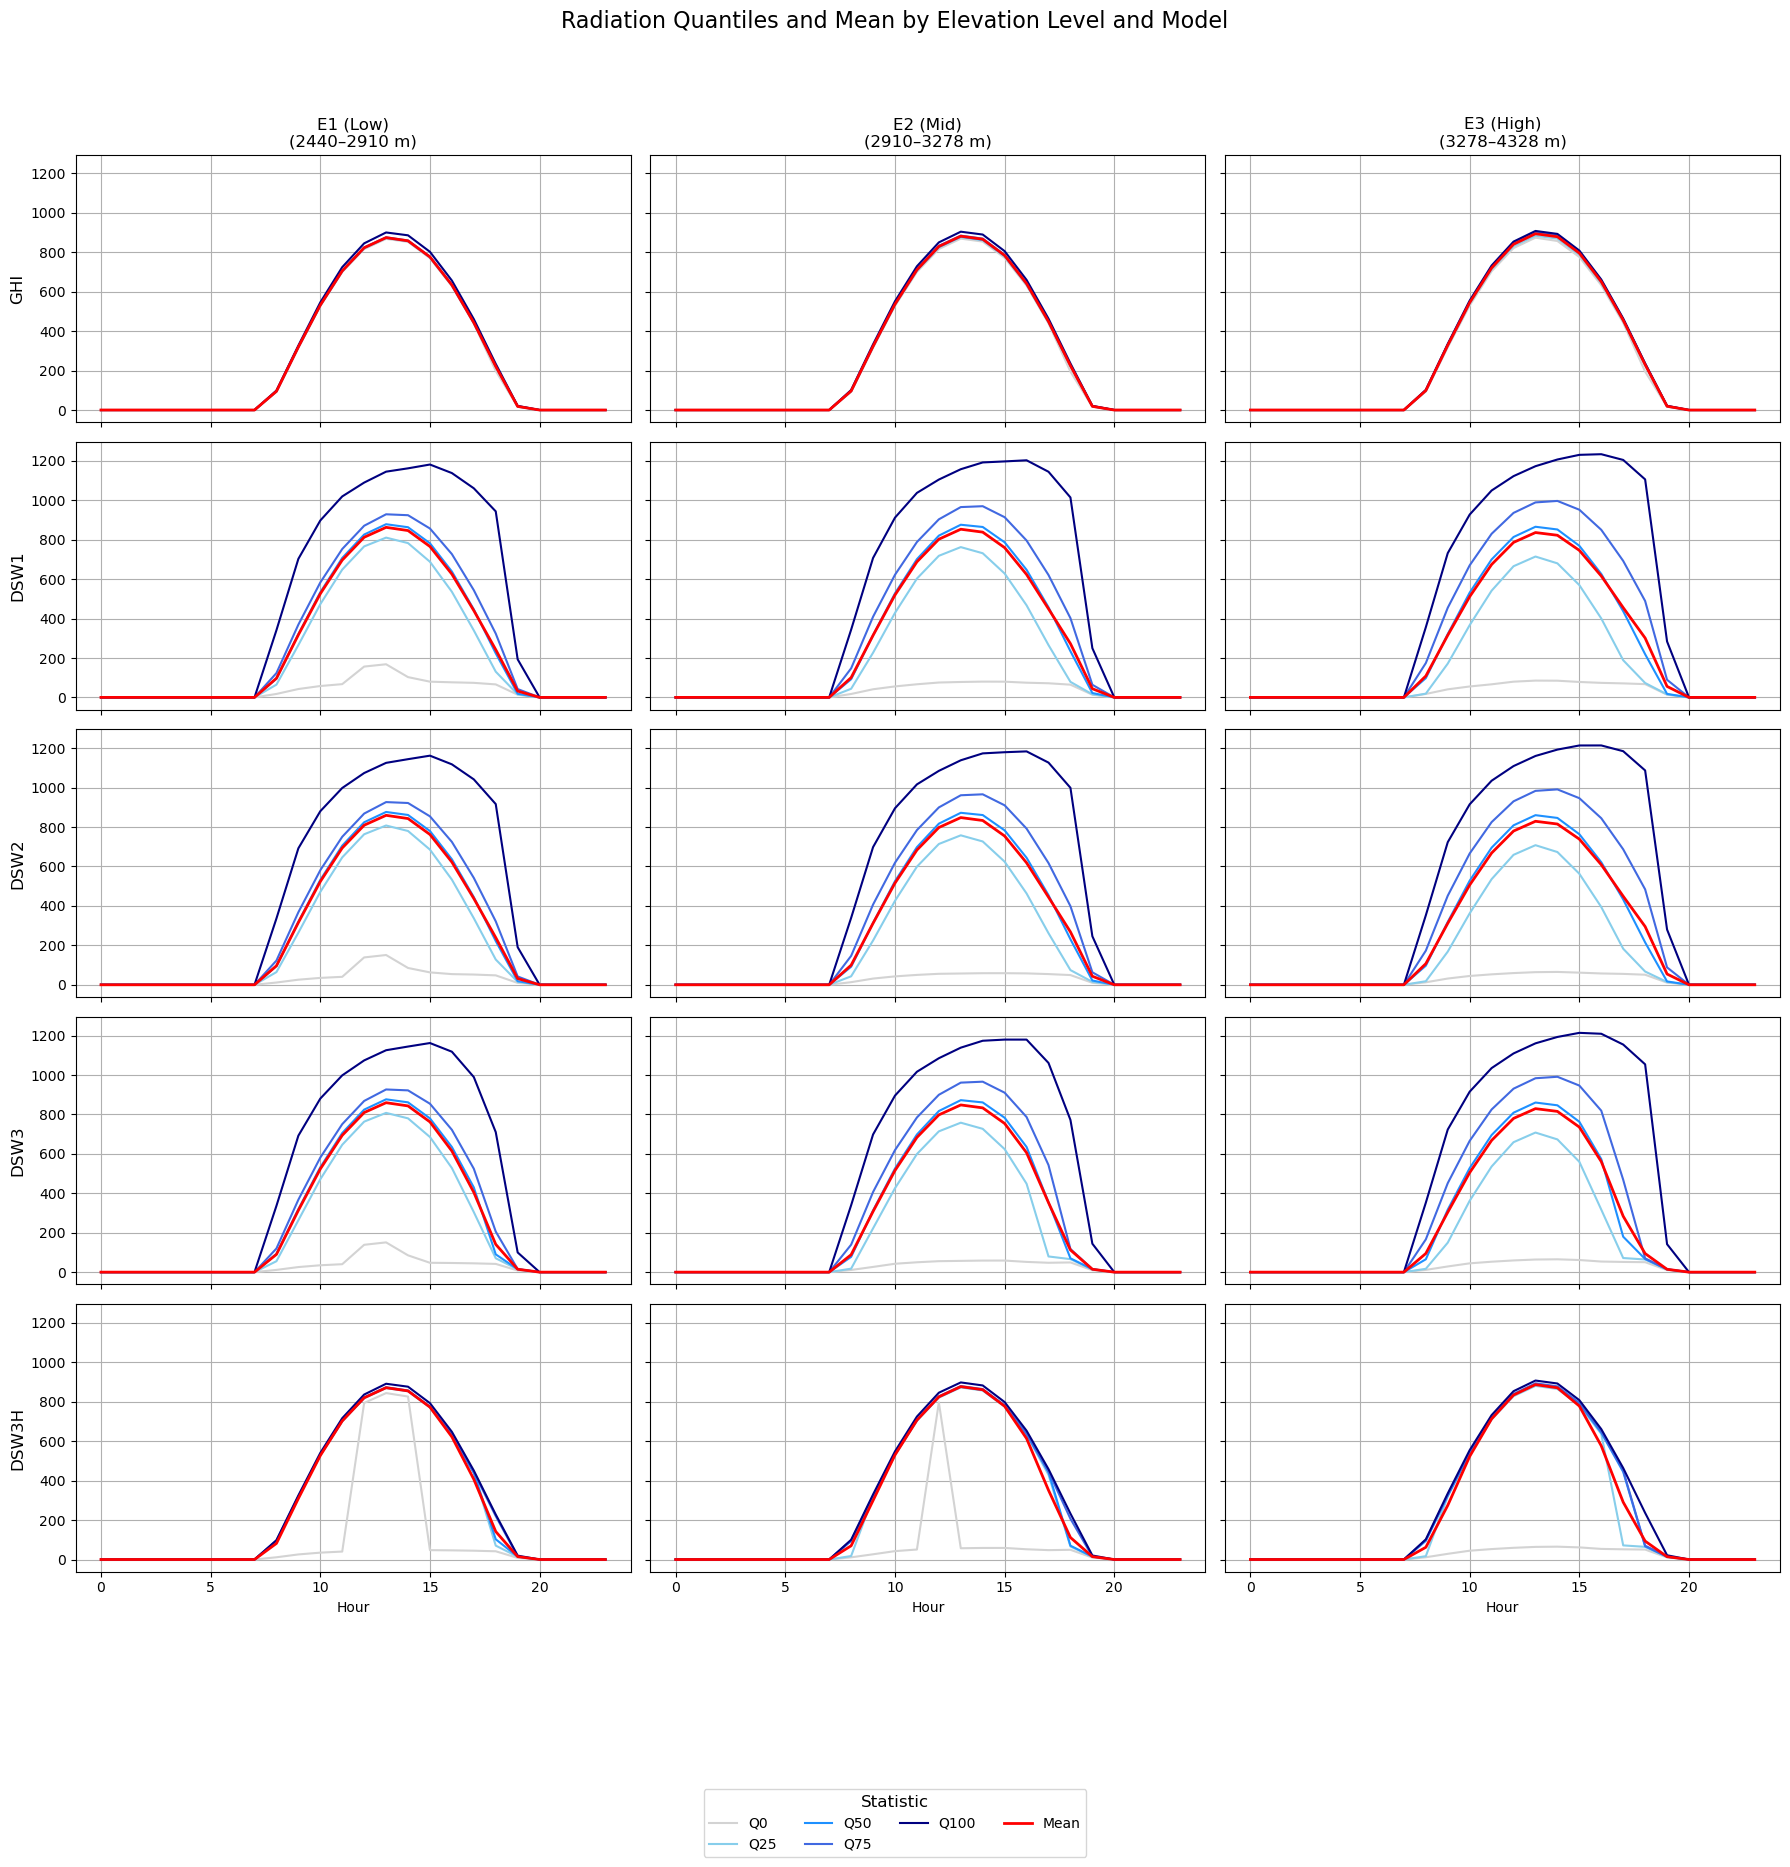

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Arrays without 'K'
arrays = {
    'GHI': ghi_stack,
    'DSW1': dsw1_stack,
    'DSW2': dsw2_stack,
    'DSW3': dsw3_stack,
    'DSW3H': dsw3h_stack
}
array_names = list(arrays.keys())
hours = np.arange(24)

# Elevation bins
n_bins = 3
bin_labels = ['E1 (Low)', 'E2 (Mid)', 'E3 (High)']
elev_edges = np.percentile(dem, np.linspace(0, 100, n_bins + 1))
elevation_masks = [
    (dem >= elev_edges[i]) & (dem < elev_edges[i + 1])
    for i in range(n_bins)
]
elevation_masks[-1] = (dem >= elev_edges[-2]) & (dem <= elev_edges[-1])  # include max

print("Elevation Bin Ranges (meters):")
for i, label in enumerate(bin_labels):
    print(f"{label}: {elev_edges[i]:.2f} m – {elev_edges[i+1]:.2f} m")

# Plot layout
fig, axes = plt.subplots(
    nrows=len(arrays), ncols=n_bins,
    figsize=(18, 18),  # Taller
    sharex=True, sharey=True
)

quantiles = [0, 25, 50, 75, 100]
q_colors = ['lightgray', 'skyblue', 'dodgerblue', 'royalblue', 'navy']
mean_color = 'red'

for row_idx, (name, arr) in enumerate(arrays.items()):
    for col_idx, (mask, bin_label) in enumerate(zip(elevation_masks, bin_labels)):
        ax = axes[row_idx, col_idx]
        masked = np.where(mask, arr, np.nan)

        # Compute quantiles for each hour
        for q, color in zip(quantiles, q_colors):
            q_vals = np.nanquantile(masked, q / 100.0, axis=(1, 2))
            ax.plot(hours, q_vals, label=f'Q{q}', color=color, linewidth=1.5)

        # Compute mean
        mean_vals = np.nanmean(masked, axis=(1, 2))
        ax.plot(hours, mean_vals, label='Mean', color=mean_color, linewidth=2)

        if row_idx == 0:
            ax.set_title(f'{bin_label}\n({elev_edges[col_idx]:.0f}–{elev_edges[col_idx+1]:.0f} m)')
        if col_idx == 0:
            ax.set_ylabel(name, fontsize=12)
        if row_idx == len(arrays) - 1:
            ax.set_xlabel('Hour')

        ax.grid(True)

# Shared legend at bottom
handles = [
    plt.Line2D([0], [0], color=color, label=f'Q{q}')
    for q, color in zip(quantiles, q_colors)
] + [plt.Line2D([0], [0], color=mean_color, label='Mean', linewidth=2)]

fig.legend(
    handles, [h.get_label() for h in handles],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    fontsize='medium',
    title='Statistic',
    title_fontsize='large'
)

plt.suptitle('Radiation Quantiles and Mean by Elevation Level and Model', fontsize=16)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()


Elevation Bin Ranges (meters):
E1 (Low): 2440.31 m – 2910.24 m
E2 (Mid): 2910.24 m – 3277.85 m
E3 (High): 3277.85 m – 4327.61 m


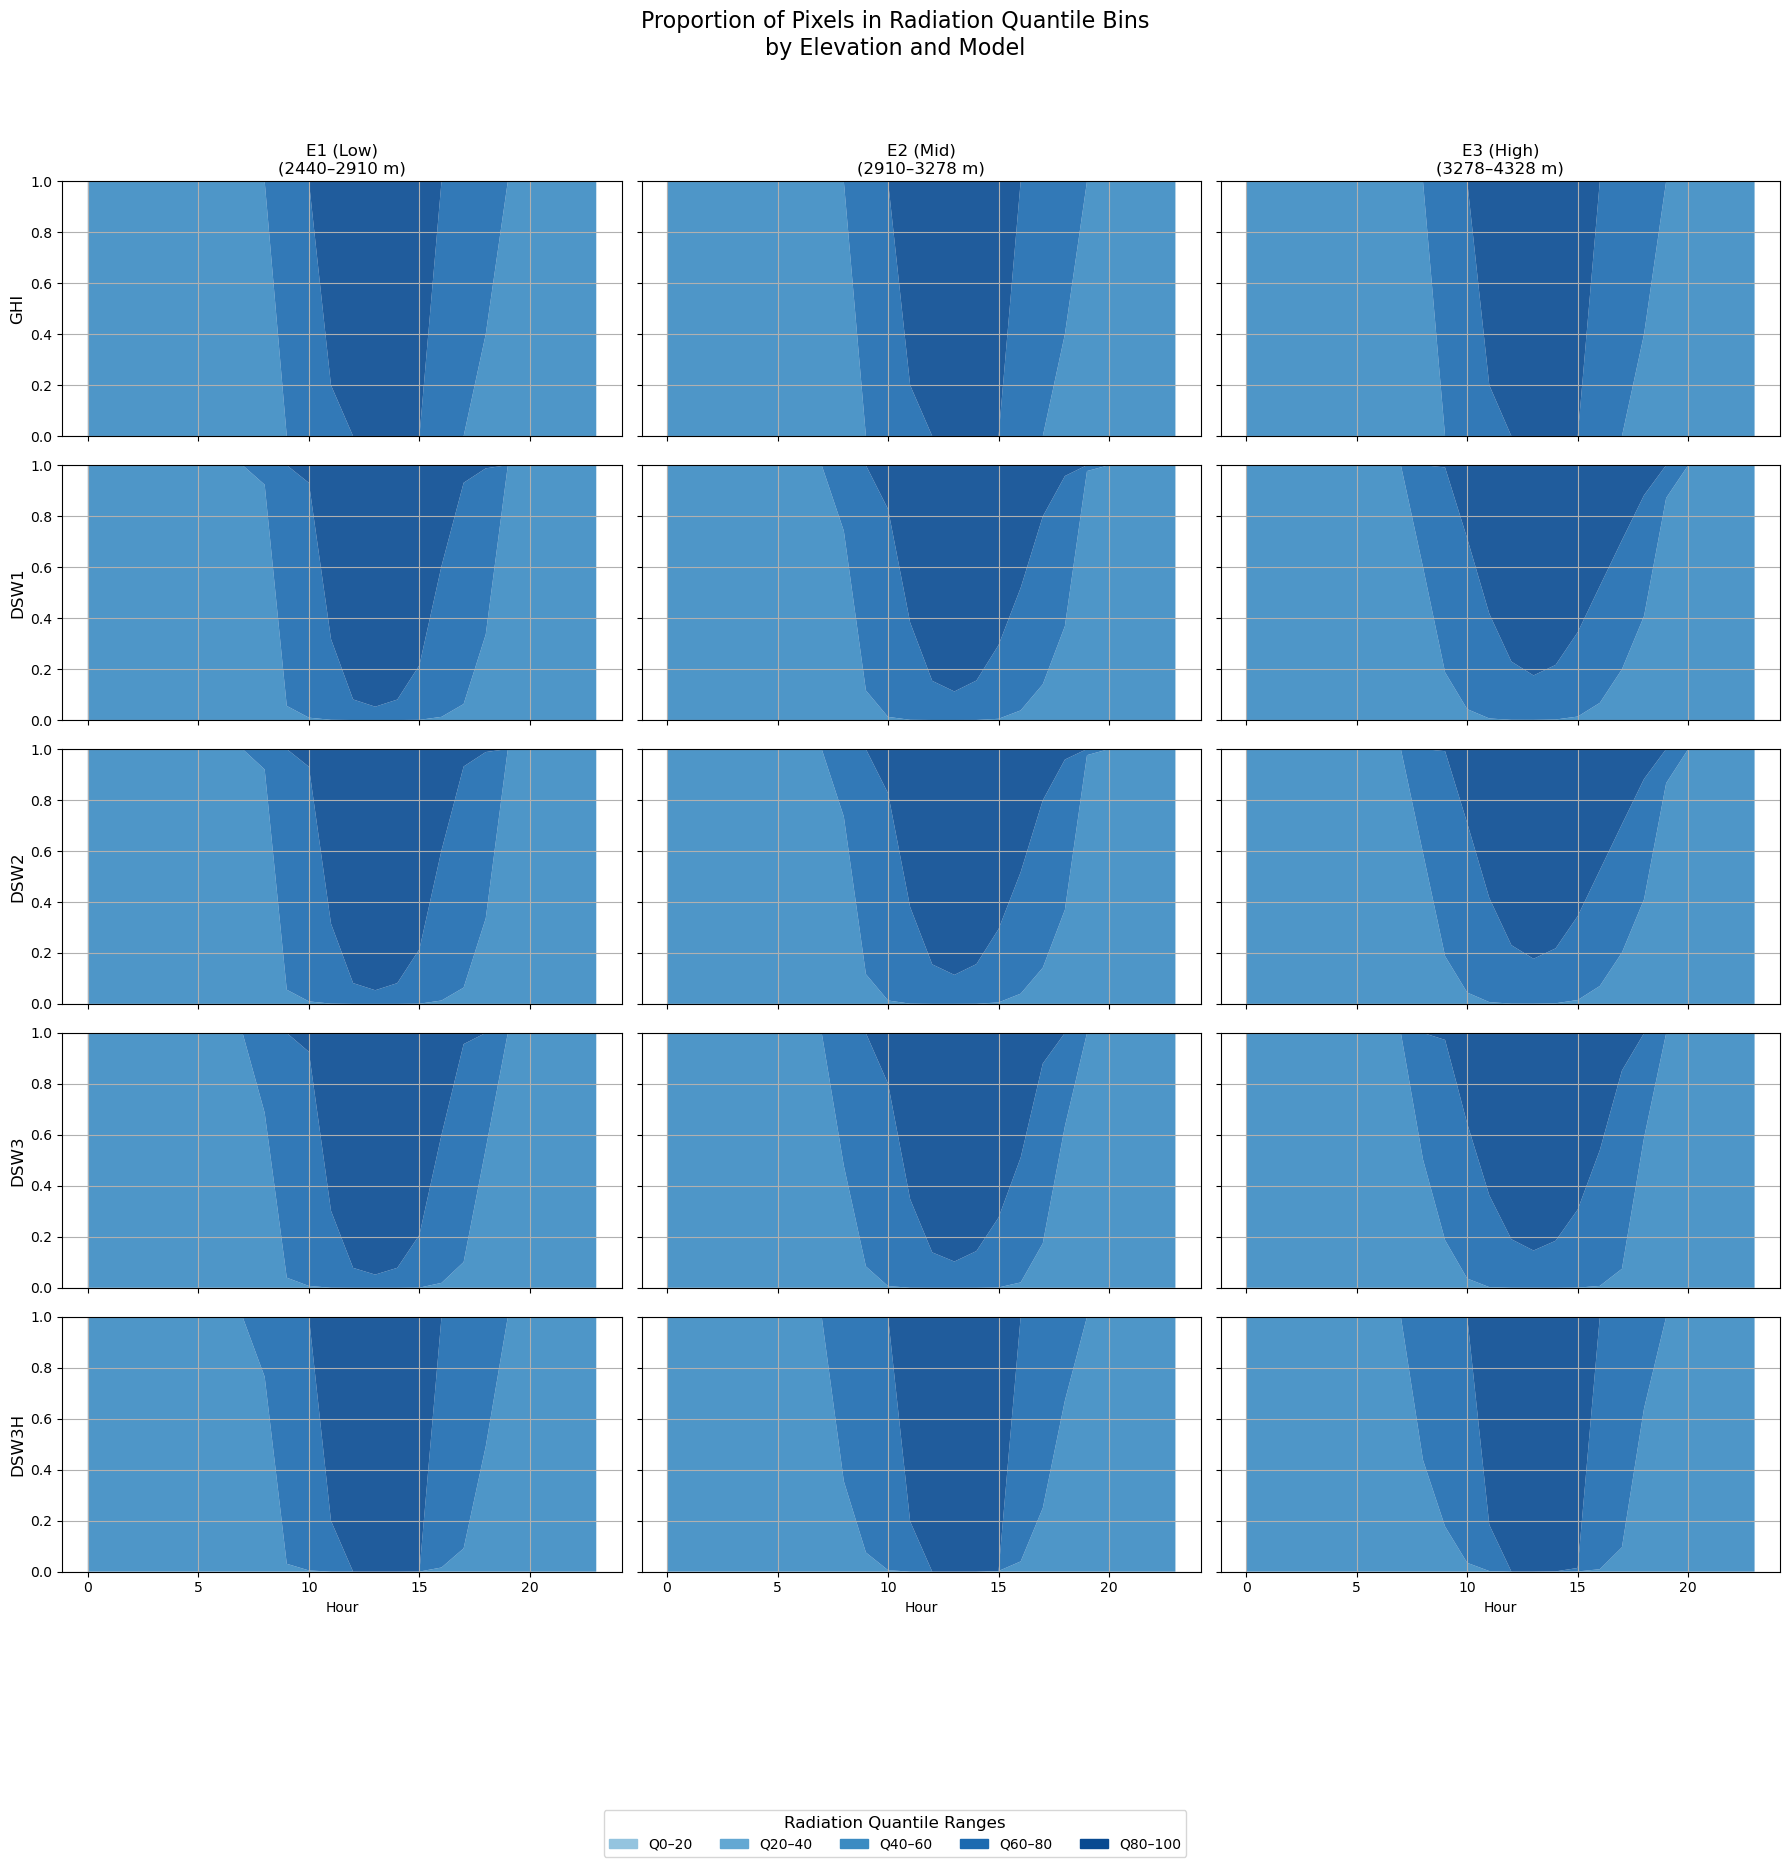

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Radiation arrays (no 'K')
arrays = {
    'GHI': ghi_stack,
    'DSW1': dsw1_stack,
    'DSW2': dsw2_stack,
    'DSW3': dsw3_stack,
    'DSW3H': dsw3h_stack
}
array_names = list(arrays.keys())
hours = np.arange(24)

# Elevation bins
n_bins = 3
bin_labels = ['E1 (Low)', 'E2 (Mid)', 'E3 (High)']
elev_edges = np.percentile(dem, np.linspace(0, 100, n_bins + 1))
elevation_masks = [
    (dem >= elev_edges[i]) & (dem < elev_edges[i + 1])
    for i in range(n_bins)
]
elevation_masks[-1] = (dem >= elev_edges[-2]) & (dem <= elev_edges[-1])  # include max

print("Elevation Bin Ranges (meters):")
for i, label in enumerate(bin_labels):
    print(f"{label}: {elev_edges[i]:.2f} m – {elev_edges[i+1]:.2f} m")

# Define quantile breaks (5 bins)
quantile_edges = [0, 20, 40, 60, 80, 100]
quantile_labels = [f'Q{quantile_edges[i]}–{quantile_edges[i+1]}' for i in range(len(quantile_edges)-1)]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(quantile_labels)))

# Setup subplot grid (rows=rad models, cols=elev bins)
fig, axes = plt.subplots(
    nrows=len(arrays), ncols=n_bins,
    figsize=(18, 18),
    sharex=True, sharey=True
)

for row_idx, (model_name, arr) in enumerate(arrays.items()):
    for col_idx, (mask, bin_label) in enumerate(zip(elevation_masks, bin_labels)):
        ax = axes[row_idx, col_idx]
        masked = np.where(mask, arr, np.nan)

        # Compute quantile edges for the masked array over all time/space
        global_q_vals = np.nanquantile(masked, np.array(quantile_edges) / 100.0)

        # Prepare counts for each bin and hour
        bin_counts = []
        for i in range(len(global_q_vals) - 1):
            bin_mask = (masked >= global_q_vals[i]) & (masked < global_q_vals[i + 1])
            count = np.sum(bin_mask, axis=(1, 2))  # per hour
            bin_counts.append(count)

        bin_counts = np.array(bin_counts)

        # Normalize to fraction of pixels in bin per hour
        total_pixels = np.sum(~np.isnan(masked), axis=(1, 2))  # per hour
        frac_bins = bin_counts / total_pixels  # shape: (bins, 24)

        # Plot stacked area chart
        ax.stackplot(hours, frac_bins, labels=quantile_labels, colors=colors, alpha=0.9)

        if row_idx == 0:
            ax.set_title(f'{bin_label}\n({elev_edges[col_idx]:.0f}–{elev_edges[col_idx+1]:.0f} m)')
        if col_idx == 0:
            ax.set_ylabel(model_name, fontsize=12)
        if row_idx == len(arrays) - 1:
            ax.set_xlabel('Hour')
        ax.set_ylim(0, 1)
        ax.grid(True)

# Legend
fig.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in colors],
    labels=quantile_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(quantile_labels),
    title='Radiation Quantile Ranges',
    title_fontsize='large',
    fontsize='medium'
)

plt.suptitle('Proportion of Pixels in Radiation Quantile Bins\nby Elevation and Model', fontsize=16)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()
